<a href="https://colab.research.google.com/github/annabellaimperatore97-s/garments-worker-productivity-ml/blob/main/Analisi_Produttivita_Tessile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerie e dataset

In [ ]:
# Lib
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from scipy.stats import pearsonr
from scipy import stats
!pip install scikit-posthocs
import scikit_posthocs as sp
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

import xgboost as xgb
import shap

from keras.models import Sequential
from keras.layers import Dense, Dropout

# Seed
np.random.seed(123)
tf.random.set_seed(123)

# Warning
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# File
from google.colab import files
uploaded = files.upload()
# Import
df = pd.read_csv('garments.csv')


Saving garments.csv to garments.csv


# Analisi esplorativa

## EDA Generale

In [ ]:
# Tipo di dato e struttura
print(df.info(), "\n")

# Statistiche descrittive
print(df.describe(), "\n")

# Valori mancanti
missing = df.isna().sum()
print("Valori mancanti per colonna:\n", missing[missing > 0], "\n")

# Curtosi e asimmetria
numeric_cols = df.select_dtypes(include=[np.number])
print("Analisi di curtosi e asimmetria:\n")
for col in numeric_cols.columns:
    kurt = numeric_cols[col].kurtosis()
    skew = numeric_cols[col].skew()
    print(f"{col:20} | Kurtosis: {kurt:.2f} | Skewness: {skew:.2f}")

# Pulizia colonne
to_drop = ['idle_time', 'idle_men', 'wip']
df = df.drop(columns=[col for col in to_drop if col in df.columns])
numeric_cols = df.select_dtypes(include=[np.number])  # Re-aggiorna

# Preview
print("\nDataFrame colonne:\n", df.columns.tolist())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

## EDA Variabile Target: Actual Productivity

In [ ]:
# Analisi descrittiva della variabile target
target_col = 'actual_productivity'

print(f"Statistiche descrittive per '{target_col}':\n")
print(df[target_col].describe())

# Verifica valori mancanti
na_target = df[target_col].isna().sum()
print(f"\nNumero di valori mancanti in '{target_col}': {na_target}")

Statistiche descrittive per 'actual_productivity':

count    1197.000000
mean        0.735091
std         0.174488
min         0.233705
25%         0.650307
50%         0.773333
75%         0.850253
max         1.120437
Name: actual_productivity, dtype: float64

Numero di valori mancanti in 'actual_productivity': 0


In [ ]:
# Capping dei valori a 1
df['actual_productivity'] = np.where(df['actual_productivity'] > 1, 1, df['actual_productivity'])

# Verifica valori non convertibili in numerico
convertibili = pd.to_numeric(df['actual_productivity'], errors='coerce')
non_convertibili = df[df['actual_productivity'].notna() & convertibili.isna()]
if not non_convertibili.empty:
    print("Valori non convertibili trovati:")
    print(non_convertibili[['actual_productivity']])
else:
    print("Tutti i valori sono convertibili in numerico.")

# Conversione vera e propria
df['actual_productivity'] = convertibili

# Riassunto finale
print("Statistiche della variabile target dopo conversione:")
print(df['actual_productivity'].describe())

# Check valori nulli post-conversione
print(f"Valori NaN dopo conversione: {df['actual_productivity'].isna().sum()}")


Tutti i valori sono convertibili in numerico.
Statistiche della variabile target dopo conversione:
count    1197.000000
mean        0.734461
std         0.173380
min         0.233705
25%         0.650307
50%         0.773333
75%         0.850253
max         1.000000
Name: actual_productivity, dtype: float64
Valori NaN dopo conversione: 0


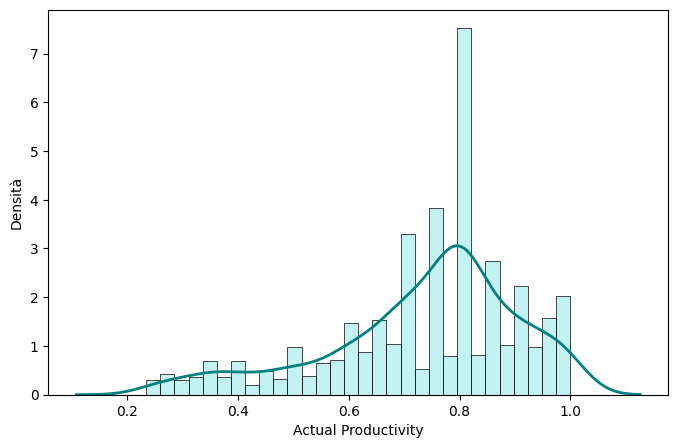

In [ ]:
plt.figure(figsize=(8, 5))

# Istogramma con colore pastello
sns.histplot(
    df['actual_productivity'],
    bins=30,
    color='#AEEEEE',
    edgecolor='black',
    linewidth=0.5,
    stat='density'
)

# Linea KDE sovrapposta
sns.kdeplot(
    df['actual_productivity'],
    color='#008080',
    linewidth=2
)

# Etichette
plt.xlabel('Actual Productivity')
plt.ylabel('Densità')
#plt.title('Distribuzione di Actual Productivity')

# Salvataggio
plt.savefig("actual_productivity_dist.png", dpi=300, bbox_inches='tight')
plt.show()


## EDA: Target Productivity


Statistiche descrittive per 'targeted_productivity':
count    1197.000000
mean        0.730159
std         0.096017
min         0.350000
25%         0.700000
50%         0.750000
75%         0.800000
max         0.800000
Name: targeted_productivity, dtype: float64


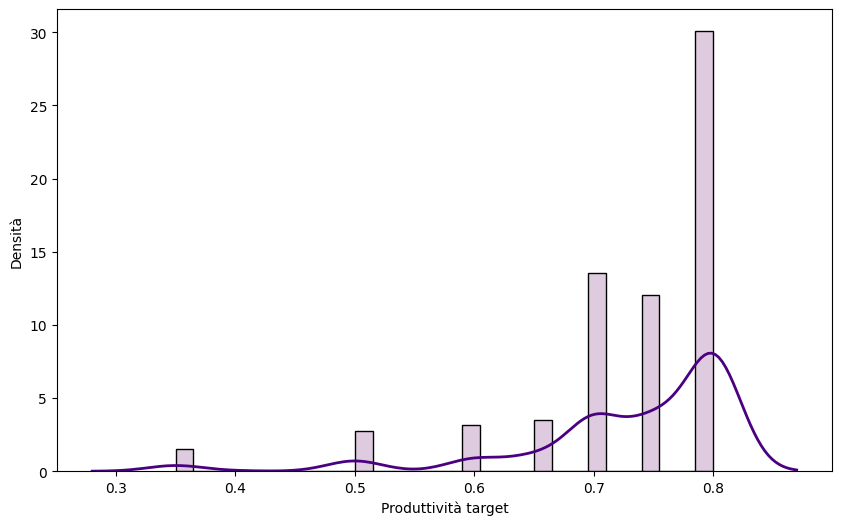

In [ ]:
# Correzione valore anomalo
df['targeted_productivity'] = df['targeted_productivity'].replace(0.07, 0.70)

# Statistiche descrittive
print("\nStatistiche descrittive per 'targeted_productivity':")
print(df['targeted_productivity'].describe())

# Distribuzione visiva
plt.figure(figsize=(10, 6))
sns.histplot(
    df['targeted_productivity'],
    bins=30,
    stat='density',
    color='#D8BFD8',
    alpha=0.8,
    edgecolor='black'
)

sns.kdeplot(df['targeted_productivity'], color='#4B0082', linewidth=2)

plt.xlabel('Produttività target')
plt.ylabel('Densità')
#plt.title('Distribuzione di Targeted Productivity')
plt.grid(False)
plt.savefig("targeted_productivity_dist.png", dpi=300, bbox_inches='tight')
plt.show()


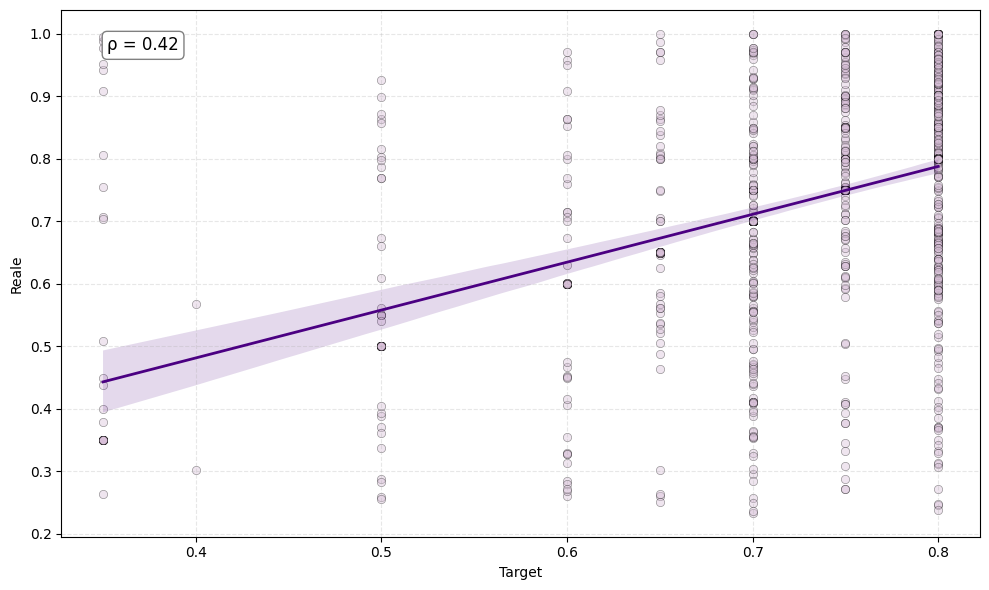

In [ ]:
# Calcolo della correlazione
corr, _ = pearsonr(df['targeted_productivity'], df['actual_productivity'])

# Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='targeted_productivity',
    y='actual_productivity',
    alpha=0.4,
    color='#D8BFD8',
    edgecolor='black'
)

sns.regplot(
    data=df,
    x='targeted_productivity',
    y='actual_productivity',
    scatter=False,
    color='#4B0082',
    line_kws={"linewidth": 2}
)

# Annotazione della correlazione
plt.text(0.05, 0.95, f'ρ = {corr:.2f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle="round", fc="white", ec="gray"))

#plt.title('Produttività target vs reale')
plt.xlabel('Target')
plt.ylabel('Reale')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


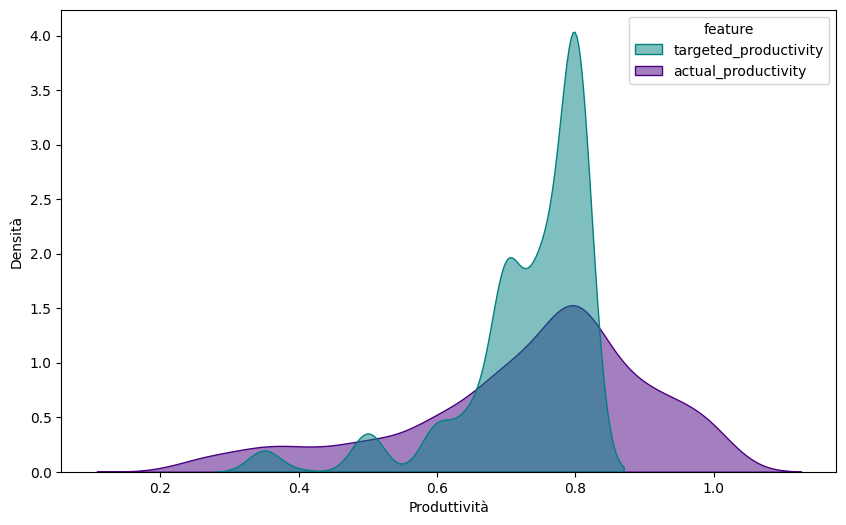

In [ ]:
# Trasformazione in formato lungo
df_long = df[['targeted_productivity', 'actual_productivity']].melt(
    var_name='feature',
    value_name='valore'
)

# Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_long,
    x='valore',
    hue='feature',
    fill=True,
    alpha=0.5,
    palette=['#008080', '#4B0082']
)

plt.xlabel('Produttività')
plt.ylabel('Densità')
#plt.titlee('Distribuzioni: Target vs Reale')
plt.grid(False)
plt.savefig("target_vs_reale_dist.png", dpi=300, bbox_inches='tight')
plt.show()


## EDA: SMV


Statistiche descrittive:
count    1197.000000
mean       15.062172
std        10.943219
min         2.900000
25%         3.940000
50%        15.260000
75%        24.260000
max        54.560000
Name: smv, dtype: float64


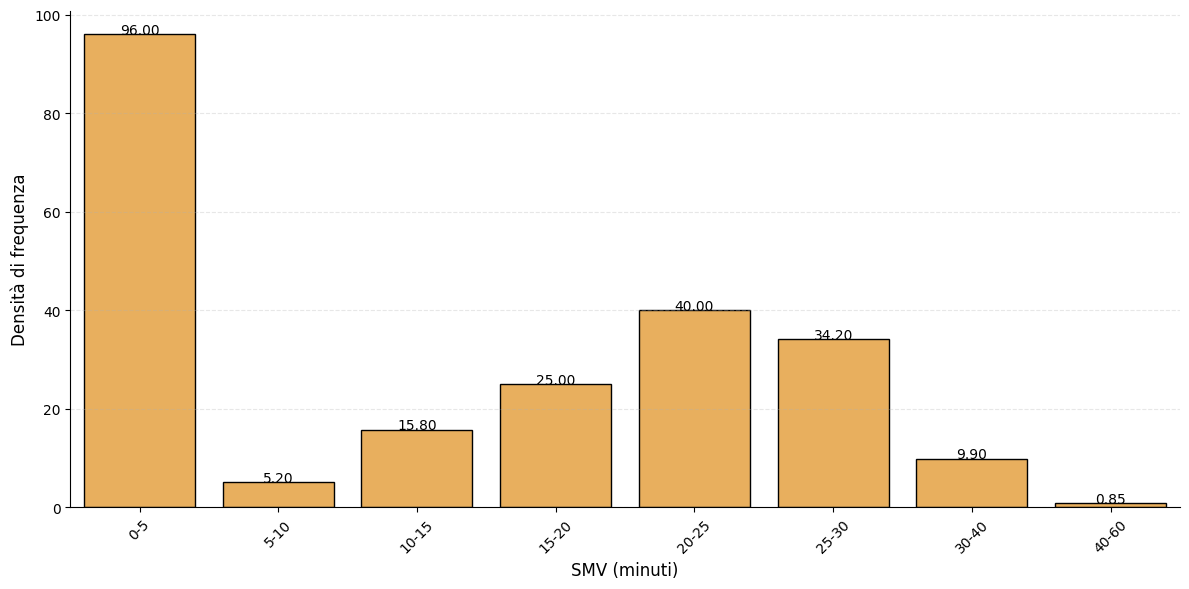

In [ ]:
# Analisi descrittiva
print("\nStatistiche descrittive:")
print(df['smv'].describe())

# Classificazione in bin
bins = [0, 5, 10, 15, 20, 25, 30, 40, 60]
labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-40', '40-60']

df['smv_class'] = pd.cut(df['smv'], bins=bins, labels=labels, include_lowest=True, right=False)

# Calcolo densità per larghezza delle classi
class_counts = df['smv_class'].value_counts().sort_index()
widths = [5, 5, 5, 5, 5, 5, 10, 20]
density = class_counts / widths

# DataFrame per il plot
plot_df = pd.DataFrame({
    'smv_class': class_counts.index,
    'count': class_counts.values,
    'density': density.values
})

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=plot_df,
    x='smv_class',
    y='density',
    color='#FFB347',
    edgecolor='black'
)

plt.xlabel('SMV (minuti)', fontsize=12)
plt.ylabel('Densità di frequenza', fontsize=12)
#plt.title('Distribuzione di SMV per classi', fontsize=14)

# Annotazione sopra le barre
for i, v in enumerate(plot_df['density']):
    ax.text(i, v + 0.005, f"{v:.2f}", ha='center', fontsize=10, color='black')

# Layout
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("smv_dist.png", dpi=300, bbox_inches='tight')
plt.show()


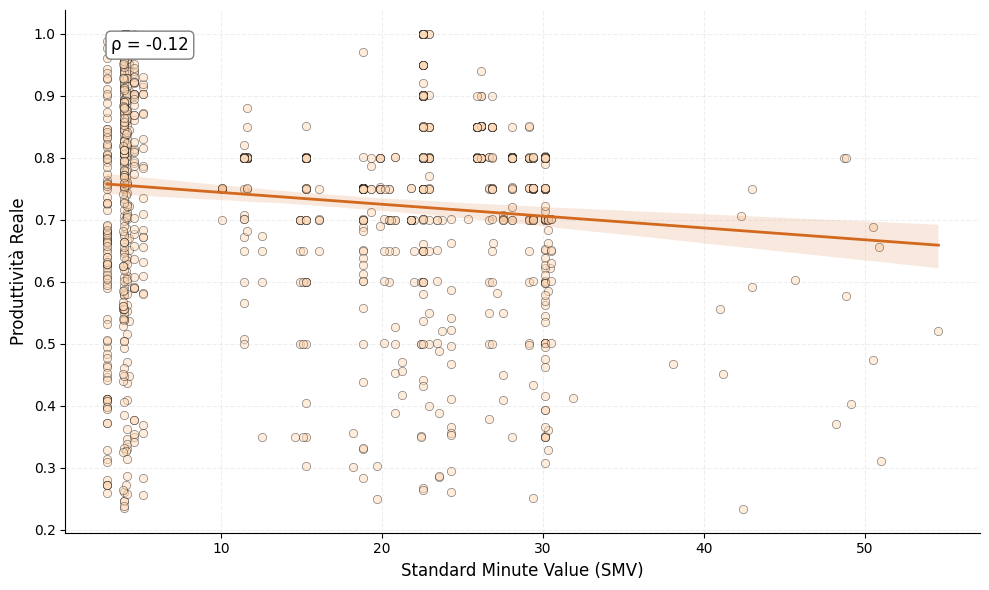

In [ ]:
# Calcolo della correlazione
corr, _ = pearsonr(df['smv'], df['actual_productivity'])

plt.figure(figsize=(10, 6))

# Scatterplot
sns.scatterplot(
    data=df,
    x='smv',
    y='actual_productivity',
    alpha=0.5,
    color='#FFDAB9',
    edgecolor='black'
)

sns.regplot(
    data=df,
    x='smv',
    y='actual_productivity',
    scatter=False,
    color='#D2691E',
    line_kws={"linewidth": 2}
)

# Annotazione del coefficiente di correlazione
plt.text(0.05, 0.95, f'ρ = {corr:.2f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle="round", fc="white", ec="gray"))

# Etichette e stile
#plt.title('Relazione tra SMV e Produttività Reale', fontsize=14, pad=20)
plt.xlabel('Standard Minute Value (SMV)', fontsize=12)
plt.ylabel('Produttività Reale', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.2)
sns.despine()
plt.tight_layout()
plt.savefig("smv_vs_productivity_reg_scatter.png", dpi=300, bbox_inches='tight')
plt.show()


## EDA: Date

month
January     542
February    443
March       212
Name: count, dtype: int64


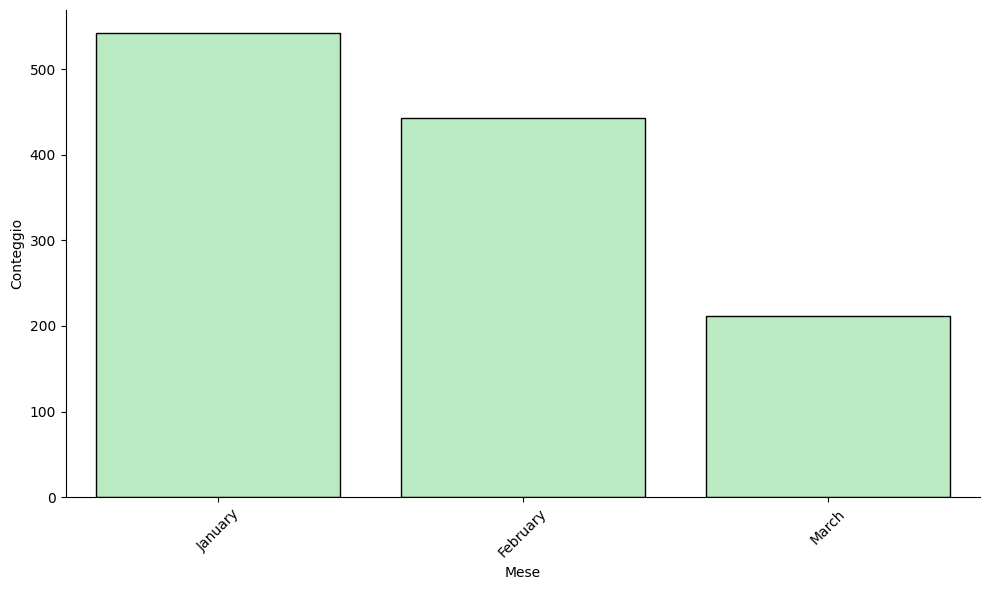

In [ ]:
# Conversione data
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y', errors='coerce')

# Estrazione mese come categoria ordinata
mesi_ordinati = ['January', 'February', 'March']

df['month'] = pd.Categorical(df['date'].dt.month_name(), categories=mesi_ordinati, ordered=True)

# Conteggio
conteggio_mesi = df['month'].value_counts().sort_index()
print(conteggio_mesi)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='month', color="#B2F2BB", edgecolor='black')

#plt.title('Frequenza delle osservazioni per mese', pad=20)
plt.xlabel('Mese')
plt.ylabel('Conteggio')

sns.despine()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("osservazioni_per_mese.png", dpi=300, bbox_inches='tight')
plt.show()


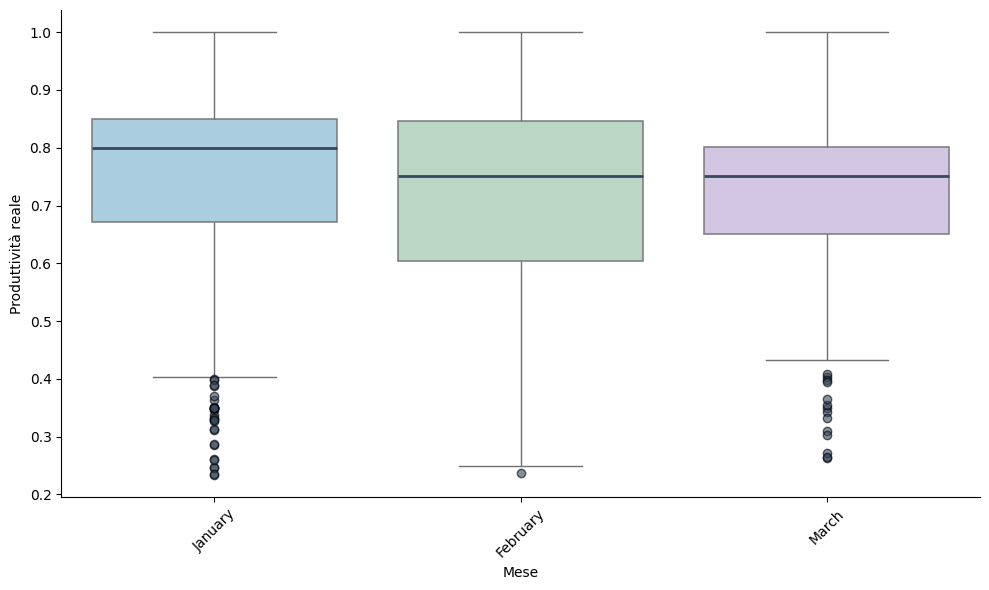

In [ ]:
palette_mesi = {
    'January': '#91C8E4',
    'February': '#A8D5BA',
    'March': '#C9B6E4'
}

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='month',
    y='actual_productivity',
    palette=palette_mesi,
    boxprops={'alpha': 0.85, 'linewidth': 1.2},
    flierprops={
        'marker': 'o',
        'markerfacecolor': '#34495E',
        'markeredgecolor': 'black',
        'markersize': 6,
        'alpha': 0.6
    },
    medianprops={'color': '#34495E', 'linewidth': 2},
    whiskerprops={'linewidth': 1},
    capprops={'linewidth': 1}
)

#plt.title('Distribuzione della produttività reale per mese', fontsize=14, pad=15)
plt.xlabel('Mese')
plt.ylabel('Produttività reale')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.savefig("month_boxplot_emph.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Rimozione colonne non più utili
df = df.drop(['date', 'quarter'], axis=1, errors='ignore')

# Verifica struttura post-pulizia
print("Colonne rimanenti nel dataset:")
print(df.columns.tolist())


Colonne rimanenti nel dataset:
['department', 'day', 'team', 'targeted_productivity', 'smv', 'over_time', 'incentive', 'no_of_style_change', 'no_of_workers', 'actual_productivity', 'smv_class', 'month']


## EDA: Over Time


Statistiche descrittive:
count     1197.000000
mean      4567.460317
std       3348.823563
min          0.000000
25%       1440.000000
50%       3960.000000
75%       6960.000000
max      25920.000000
Name: over_time, dtype: float64


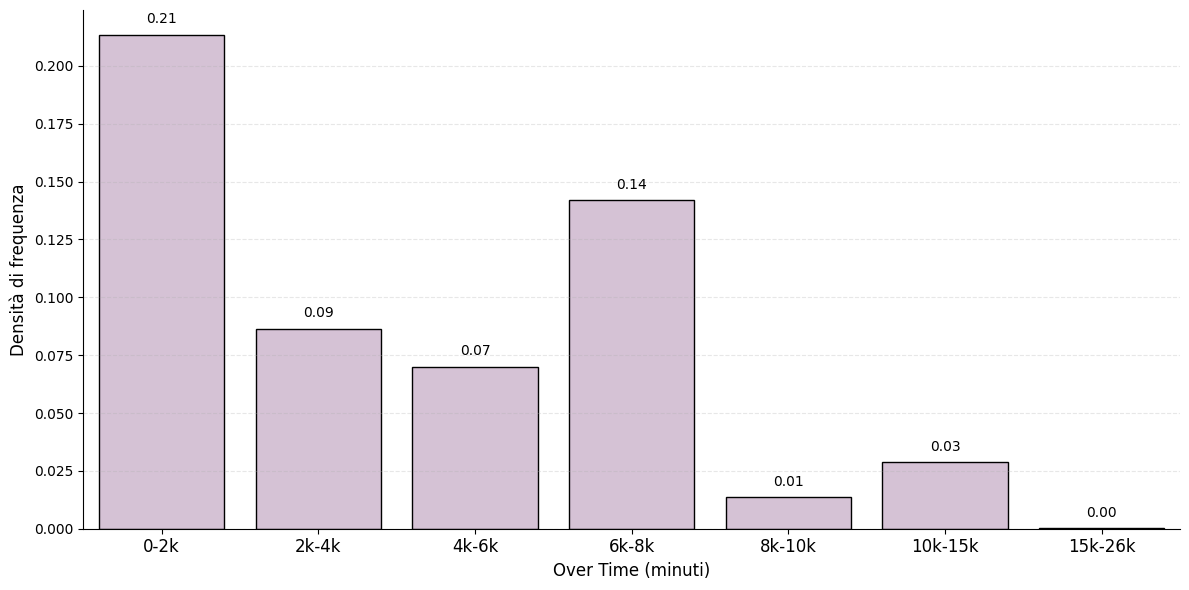

In [ ]:
# Statistiche descrittive
print("\nStatistiche descrittive:")
print(df['over_time'].describe())

# Definizione classi
bins = [0, 2000, 4000, 6000, 8000, 10000, 15000, 26000]
labels = ["0-2k", "2k-4k", "4k-6k", "6k-8k", "8k-10k", "10k-15k", "15k-26k"]

# Creazione classi
df['over_time_class'] = pd.cut(df['over_time'], bins=bins, labels=labels, include_lowest=True)

# Calcolo densità
freq_table = df['over_time_class'].value_counts().sort_index().reset_index()
freq_table.columns = ['class', 'count']
freq_table['bin_width'] = np.diff(bins)
freq_table['density'] = freq_table['count'] / freq_table['bin_width']

# Barplot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=freq_table,
    x='class',
    y='density',
    color='#D8BFD8',
    edgecolor='black',
    linewidth=1
)

plt.xlabel('Over Time (minuti)', fontsize=12)
plt.ylabel('Densità di frequenza', fontsize=12)
#plt.title('Distribuzione Over Time per classi', fontsize=14, pad=15)

# Annotazioni sopra le barre
for i, v in enumerate(freq_table['density']):
    ax.text(i, v + 0.005, f"{v:.2f}", ha='center', fontsize=10, color='black')

# Layout
sns.despine()
plt.xticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("over_time_dist.png", dpi=300, bbox_inches='tight')
plt.show()


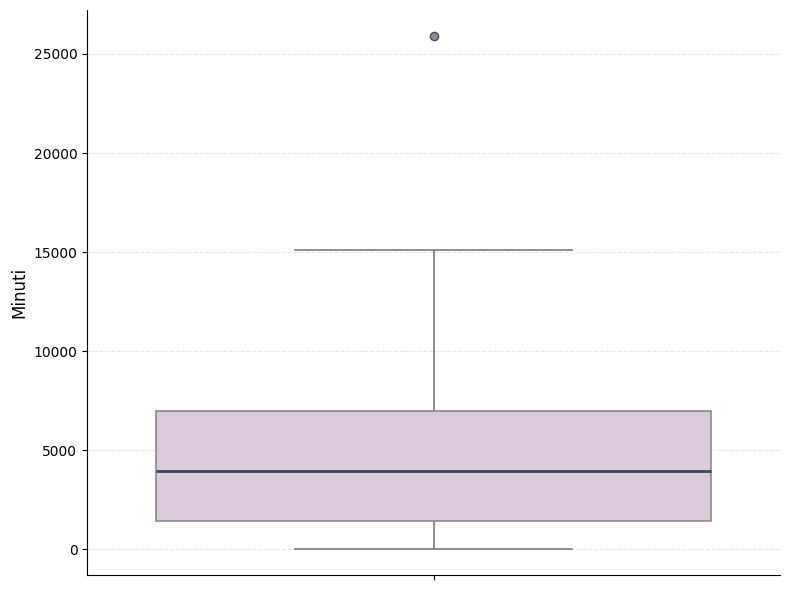

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    y=df['over_time'],
    color='#D8BFD8',
    linewidth=1.2,
    fliersize=6,
    flierprops=dict(
        marker='o',
        markerfacecolor='#34495E',
        markeredgecolor='black',
        markersize=6,
        alpha=0.6
    ),
    medianprops=dict(color='#34495E', linewidth=2),
    boxprops=dict(alpha=0.85)
)

#plt.title('Boxplot Over Time', pad=20, fontsize=14)
plt.ylabel('Minuti', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("over_time_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Calcolo outlier assoluti
soglia_outlier = df['over_time'].quantile(0.99)
outliers = df[df['over_time'] > soglia_outlier].copy()

print(f"Soglia outlier (99° percentile): {soglia_outlier:.2f} minuti")
print(f"Totale outlier rilevati: {outliers.shape[0]}")

print("\nOutliers sopra la soglia:")
print(
    outliers[[
        'department', 'day', 'team', 'targeted_productivity', 'smv',
        'over_time', 'incentive', 'no_of_style_change', 'no_of_workers',
        'actual_productivity', 'month', 'over_time_class'
    ]]
    .sort_values('over_time', ascending=False)
    .reset_index(drop=True)
    .head(10)
)

# Calcolo over_time per lavoratore (protezione su divisione)
df['over_time_per_worker'] = df['over_time'] / df['no_of_workers'].replace(0, np.nan)

filtered = df[df['over_time'] > 10000].sort_values('over_time_per_worker', ascending=False)

print("\nDati con over_time > 10000, ordinati per over_time_per_worker:")
print(
    filtered[[
        'department', 'day', 'team', 'targeted_productivity', 'smv',
        'over_time', 'incentive', 'no_of_style_change', 'no_of_workers',
        'actual_productivity', 'month', 'over_time_class', 'over_time_per_worker'
    ]]
    .reset_index(drop=True)
    .head(10)
)


Soglia outlier (99° percentile): 10620.00 minuti
Totale outlier rilevati: 10

Outliers sopra la soglia:
   department       day  team  targeted_productivity    smv  over_time  \
0      sweing  Thursday    11                   0.35  12.52      25920   
1      sweing  Thursday    12                   0.80  11.61      15120   
2  finishing   Thursday     2                   0.70   3.94      15000   
3  finishing   Thursday     1                   0.70   3.94      15000   
4      sweing  Thursday     6                   0.80  11.41      14640   
5      sweing  Saturday     4                   0.70  23.69      13800   
6  finishing   Thursday     4                   0.80   3.94      12600   
7      sweing  Thursday     1                   0.70  22.94      12180   
8  finishing   Thursday     3                   0.70   3.94      12000   
9      sweing  Thursday     8                   0.80  40.99      10770   

   incentive  no_of_style_change  no_of_workers  actual_productivity    month  \


Righe rimosse (over_time == 25920): 1


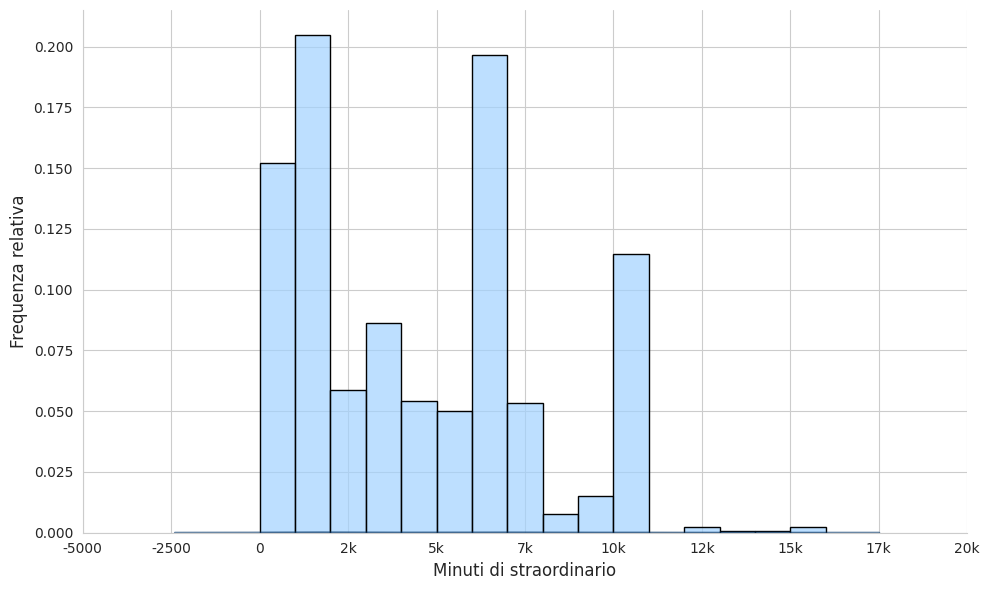

In [ ]:
# Rimozione valore anomalo
df_filtered = df[df['over_time'] != 25920].copy()
print(f"Righe rimosse (over_time == 25920): {df[df['over_time'] == 25920].shape[0]}")

# Istogramma
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.histplot(
    data=df_filtered,
    x='over_time',
    bins=np.arange(0, df_filtered['over_time'].max()+1000, 1000),
    stat='probability',
    color='#A2D2FF',
    edgecolor='black',
    alpha=0.7
)

sns.kdeplot(
    data=df_filtered,
    x='over_time',
    color='#003366',
    linewidth=1.5,
    ax=ax,
    alpha=0.6
)

plt.xlabel('Minuti di straordinario', fontsize=12)
plt.ylabel('Frequenza relativa', fontsize=12)

# Etichette asse X in "k"
xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f"{int(x)//1000}k" if x >= 1000 else int(x) for x in xticks])

sns.despine()
plt.tight_layout()
plt.savefig("over_time_dist.png", dpi=300, bbox_inches='tight')
plt.show()


## EDA: Day

Conteggio osservazioni per giorno:
      Giorno  Numero osservazioni
0     Monday                  199
1    Tuesday                  201
2  Wednesday                  208
3   Thursday                  199
4   Saturday                  187
5     Sunday                  203


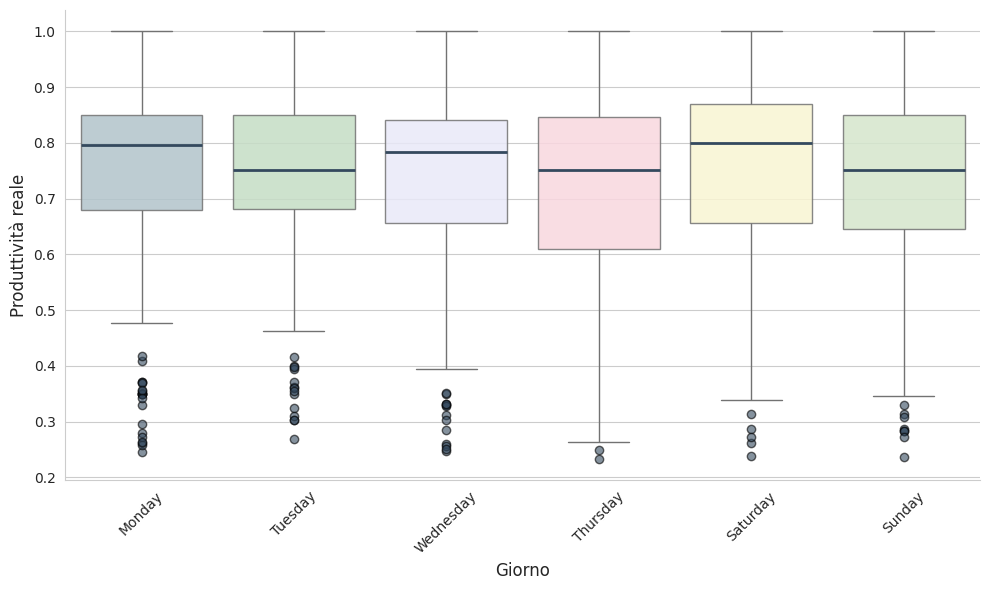

In [ ]:
# Conversione day in ordinale
df['day'] = pd.Categorical(df['day'],
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Saturday', 'Sunday'],
    ordered=True
)

# Conteggio per giorno
day_counts = df['day'].value_counts().sort_index()
print("Conteggio osservazioni per giorno:")
print(day_counts.rename_axis("Giorno").reset_index(name="Numero osservazioni"))

# Palette coerente
palette_giorni = {
    'Monday': '#AEC6CF',
    'Tuesday': '#C1E1C1',
    'Wednesday': '#E6E6FA',
    'Thursday': '#FFD1DC',
    'Saturday': '#FFFACD',
    'Sunday': '#D4EAC8'
}

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='day',
    y='actual_productivity',
    palette=palette_giorni,
    boxprops={'alpha': 0.85},
    flierprops=dict(marker='o', markerfacecolor='#34495E', markeredgecolor='black', alpha=0.6),
    medianprops={'color': '#34495E', 'linewidth': 2}
)

#plt.title('Produttività reale per giorno della settimana', pad=20, fontsize=14)
plt.xlabel('Giorno', fontsize=12)
plt.ylabel('Produttività reale', fontsize=12)

plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.savefig("productivity_by_day.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Mediana della produttività per giorno
mediana_prod_giorno = (
    df.groupby('day')['actual_productivity']
    .median()
    .reset_index()
    .rename(columns={'actual_productivity': 'mediana_prod'})
    .sort_values('mediana_prod', ascending=False)
)

print("Mediana della produttività per giorno:")
print(mediana_prod_giorno.to_string(index=False))

Mediana della produttività per giorno:
      day  mediana_prod
 Saturday      0.800117
   Monday      0.795417
Wednesday      0.783212
  Tuesday      0.750797
 Thursday      0.750651
   Sunday      0.750651


## EDA: Numero dei lavoratori

Statistiche descrittive:
count    1197.00
mean       34.61
std        22.20
min         2.00
25%         9.00
50%        34.00
75%        57.00
max        89.00
Name: no_of_workers, dtype: float64


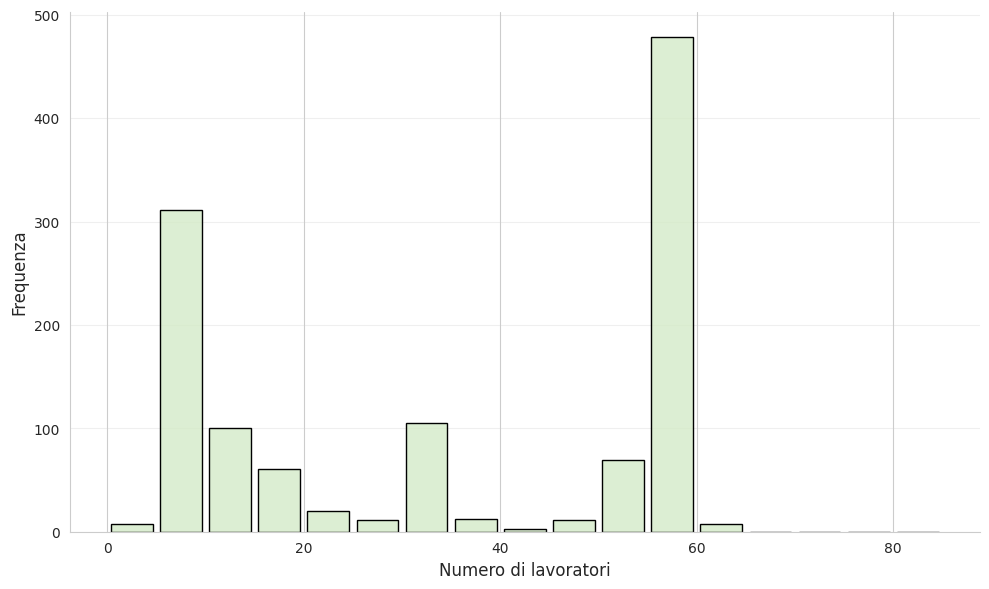

In [ ]:
# Statistiche descrittive
print("Statistiche descrittive:")
print(df['no_of_workers'].describe().round(2))

# Istogramma con miglioramenti estetici
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.histplot(
    data=df,
    x='no_of_workers',
    bins=range(0, 90, 5),
    color='#D4EAC8',  # verde salvia chiaro
    edgecolor='black',
    alpha=0.8,
    shrink=0.85
)

plt.xlabel('Numero di lavoratori', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
#plt.title('Distribuzione del numero di lavoratori', fontsize=14, pad=15)

plt.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig("no_of_workers_dist.png", dpi=300, bbox_inches='tight')
plt.show()


Osservazioni con 89 lavoratori: 1
Team with 89 workers:
department  team  targeted_productivity   smv  over_time  incentive  no_of_style_change  no_of_workers  actual_productivity   month over_time_class
    sweing     6                    0.8 11.61       5760         75                   0           89.0             0.850411 January           4k-6k


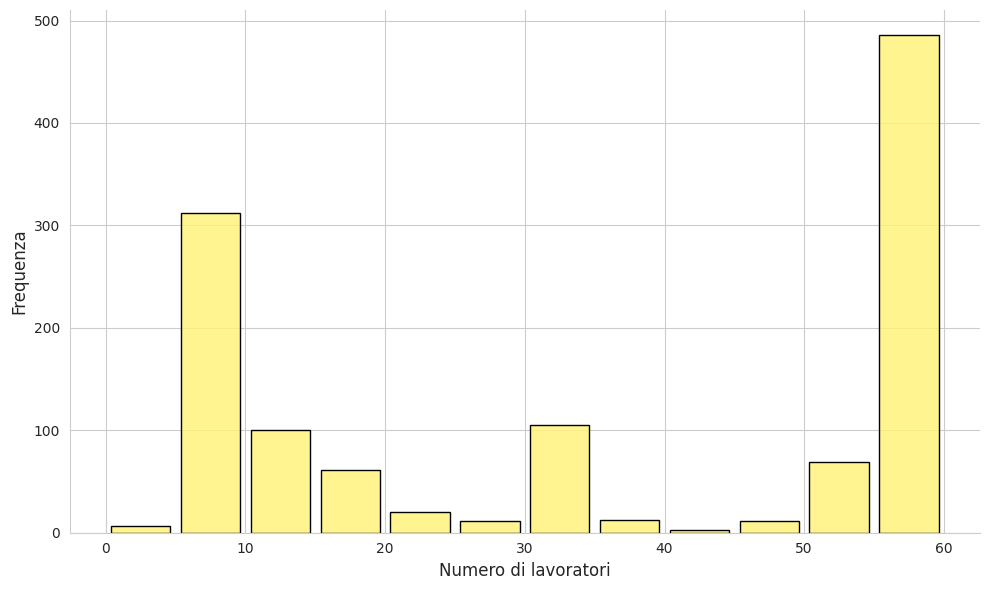

Statistiche aggiornate su no_of_workers:
count    1197.00
mean       34.54
std        22.16
min         2.00
25%         9.00
50%        34.00
75%        57.00
max        60.00
Name: no_of_workers, dtype: float64


In [ ]:
# Ispezione team con 89 lavoratori
team_89 = df[df['no_of_workers'] == 89]
print(f"Osservazioni con 89 lavoratori: {team_89.shape[0]}")
print("Team with 89 workers:")
print(team_89[[
    'department', 'team', 'targeted_productivity', 'smv',
    'over_time', 'incentive', 'no_of_style_change',
    'no_of_workers', 'actual_productivity', 'month',
    'over_time_class'
]].to_string(index=False))

# Correzione del valore anomalo (presunto errore di battitura)
df['no_of_workers'] = df['no_of_workers'].replace(89, 8)

# Istogramma aggiornato
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.histplot(
    data=df,
    x='no_of_workers',
    bins=range(0, int(df['no_of_workers'].max())+5, 5),
    color='#FFF275',
    edgecolor='black',
    alpha=0.8,
    shrink=0.85
)

plt.xlabel('Numero di lavoratori', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
#plt.title('Distribuzione corretta del numero di lavoratori', fontsize=14, pad=15)

sns.despine()
plt.tight_layout()
plt.savefig("no_of_workers_dist_cleaned.png", dpi=300, bbox_inches='tight')
plt.show()

# Statistiche aggiornate
print("Statistiche aggiornate su no_of_workers:")
print(df['no_of_workers'].describe().round(2))


## EDA: Incentive

Statistiche descrittive:
count    1197.000000
mean       38.210526
std       160.182643
min         0.000000
25%         0.000000
50%         0.000000
75%        50.000000
max      3600.000000
Name: incentive, dtype: float64


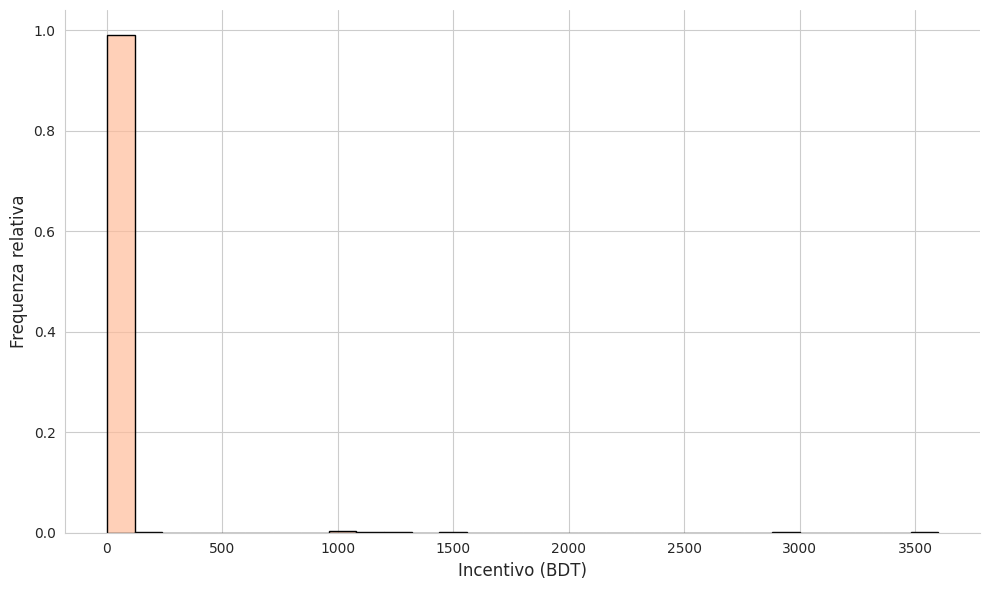

In [ ]:
print("Statistiche descrittive:")
print(df['incentive'].describe())

# Istogramma della variabile 'incentive'
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.histplot(
    data=df,
    x='incentive',
    bins=30,
    stat='probability',
    color='#FFBC9A',  # arancio chiaro pastello
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Incentivo (BDT)", fontsize=12)
plt.ylabel("Frequenza relativa", fontsize=12)
#plt.title("Distribuzione degli incentivi", fontsize=14, pad=15)

sns.despine()
plt.tight_layout()
plt.savefig("incentive_dist.png", dpi=300, bbox_inches='tight')
plt.show()


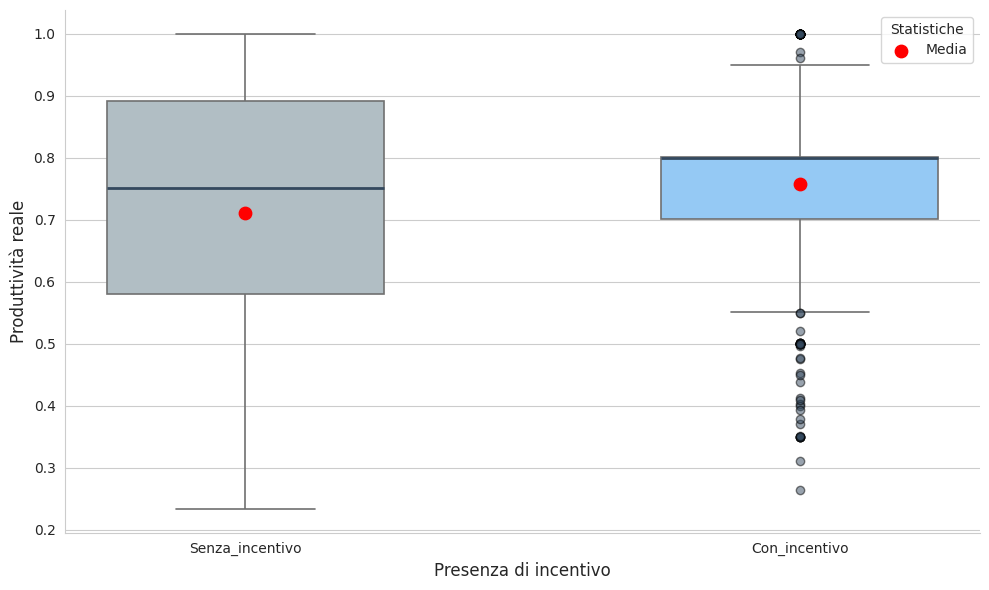

In [ ]:
# Creazione variabile categorica incentivo
df['has_incentive'] = pd.Categorical(
    np.where(df['incentive'] > 0, 'Con_incentivo', 'Senza_incentivo'),
    categories=['Senza_incentivo', 'Con_incentivo'],
    ordered=True
)

# Boxplot con medie
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

palette_custom = {
    'Senza_incentivo': '#B0BEC5',  # grigio azzurrato
    'Con_incentivo': '#90CAF9'     # azzurro pastello
}

ax = sns.boxplot(
    data=df,
    x='has_incentive',
    y='actual_productivity',
    palette=palette_custom,
    width=0.5,
    linewidth=1.2,
    fliersize=4,
    saturation=0.9,
    medianprops=dict(color='#34495E', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='#34495E',
                    markeredgecolor='black', markersize=6, alpha=0.5)
)

# Titoli e assi
#plt.title("Produttività reale in base alla presenza di incentivo", pad=20, fontsize=14)
plt.xlabel("Presenza di incentivo", fontsize=12)
plt.ylabel("Produttività reale", fontsize=12)

# Aggiunta della media
means = df.groupby('has_incentive')['actual_productivity'].mean()
for i, mean_val in enumerate(means):
    ax.scatter(i, mean_val, color='red', s=80, zorder=5, label='Media' if i == 0 else "")

# Layout
plt.legend(title="Statistiche")
sns.despine()
plt.tight_layout()
plt.savefig("incentive_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


     has_incentive    n  percentuale
1    Con_incentivo  593         49.5
0  Senza_incentivo  604         50.5


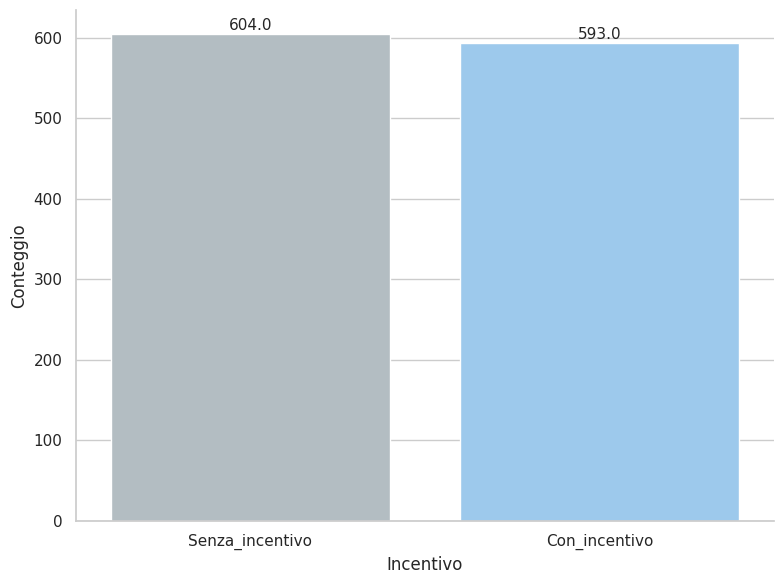

In [ ]:
result = (
    df.groupby('has_incentive', observed=True).size()
    .reset_index(name='n')
)
result['percentuale'] = round(result['n'] / result['n'].sum() * 100, 1)
result = result.sort_values('has_incentive', ascending=False)
print(result)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
bar_plot = sns.countplot(
    data=df,
    x="has_incentive",
    palette=["#B0BEC5", "#90CAF9"]  # Grigio e azzurro pastello coerenti
)

# Aggiungi etichette sulle barre
for p in bar_plot.patches:
    height = p.get_height()
    bar_plot.annotate(f'{height}', (p.get_x() + p.get_width()/2., height + 5),
                      ha='center', fontsize=11)

#plt.title("Frequenza delle osservazioni per presenza di incentivo", fontsize=14, pad=15)
plt.xlabel("Incentivo", fontsize=12)
plt.ylabel("Conteggio", fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig("has_incentive_barplot.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Elimino colonne in eccesso
df = df.drop('incentive', axis = 1)

# Verifica struttura post-pulizia
print("Colonne rimanenti nel dataset:")
print(df.columns.tolist())


Colonne rimanenti nel dataset:
['department', 'day', 'team', 'targeted_productivity', 'smv', 'over_time', 'no_of_style_change', 'no_of_workers', 'actual_productivity', 'smv_class', 'month', 'over_time_class', 'over_time_per_worker', 'has_incentive']


## EDA: Department

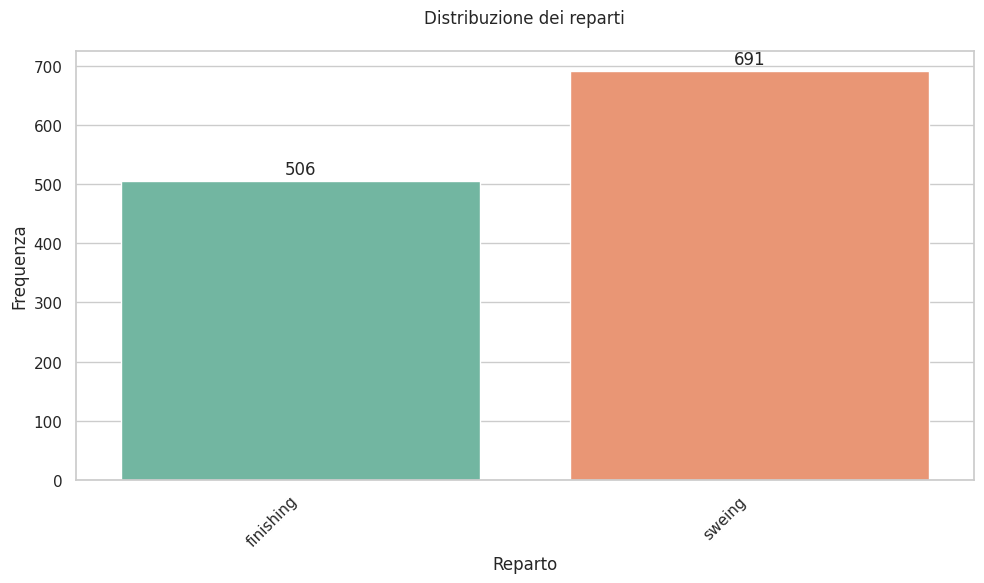

In [ ]:
# Pulizia valori department
df['department'] = df['department'].str.strip().str.lower()
df['department'] = df['department'].astype('category')

# Barplot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x='department',
    palette = "Set2"
)

ax.set_title('Distribuzione dei reparti', pad=20)
ax.set_xlabel('Reparto')
ax.set_ylabel('Frequenza')

plt.xticks(rotation=45, ha='right')

# Etichette sulle barre (opzionale)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

plt.tight_layout()
plt.savefig("department_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


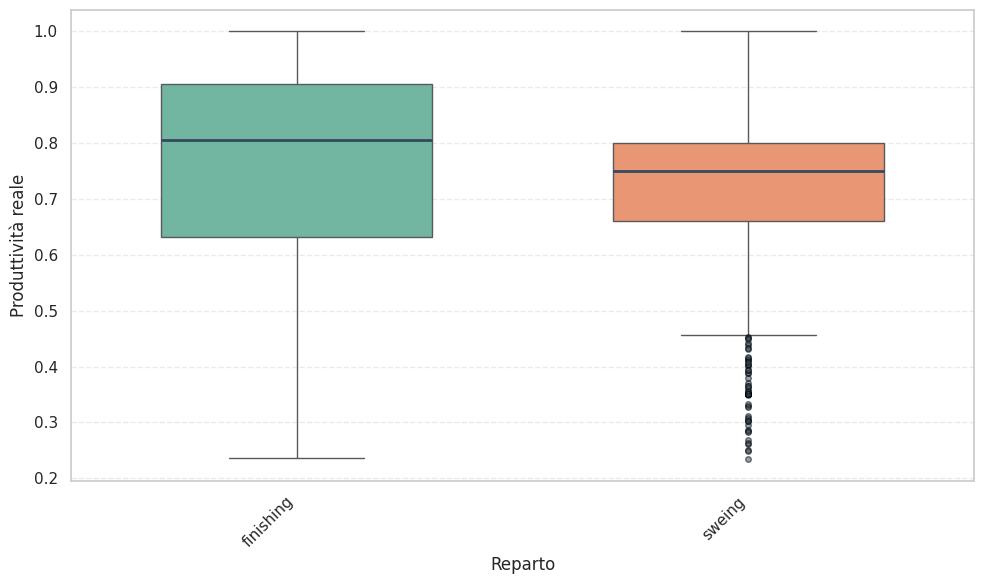

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df,
    x="department",
    y="actual_productivity",
    palette="Set2",
    width=0.6,
    fliersize=3,
    medianprops=dict(color="#34495E", linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='#34495E',
                    markeredgecolor='black', markersize=4, alpha=0.5)
)

ax.set_xlabel("Reparto", fontsize=12)
ax.set_ylabel("Produttività reale", fontsize=12)

plt.xticks(rotation=45, ha='right')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("department_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


## EDA: Team

In [ ]:
# Conversione in categoria
df['team'] = df['team'].astype('category')

# Conteggio e ordinamento
team_counts = df['team'].value_counts().reset_index()
team_counts.columns = ['team', 'n']
team_counts = team_counts.sort_values('n', ascending=False)

print(team_counts)


   team    n
0     2  109
1     8  109
2     4  105
3     1  105
4     9  104
5    10  100
6    12   99
7     7   96
8     3   95
9     6   94
10    5   93
11   11   88


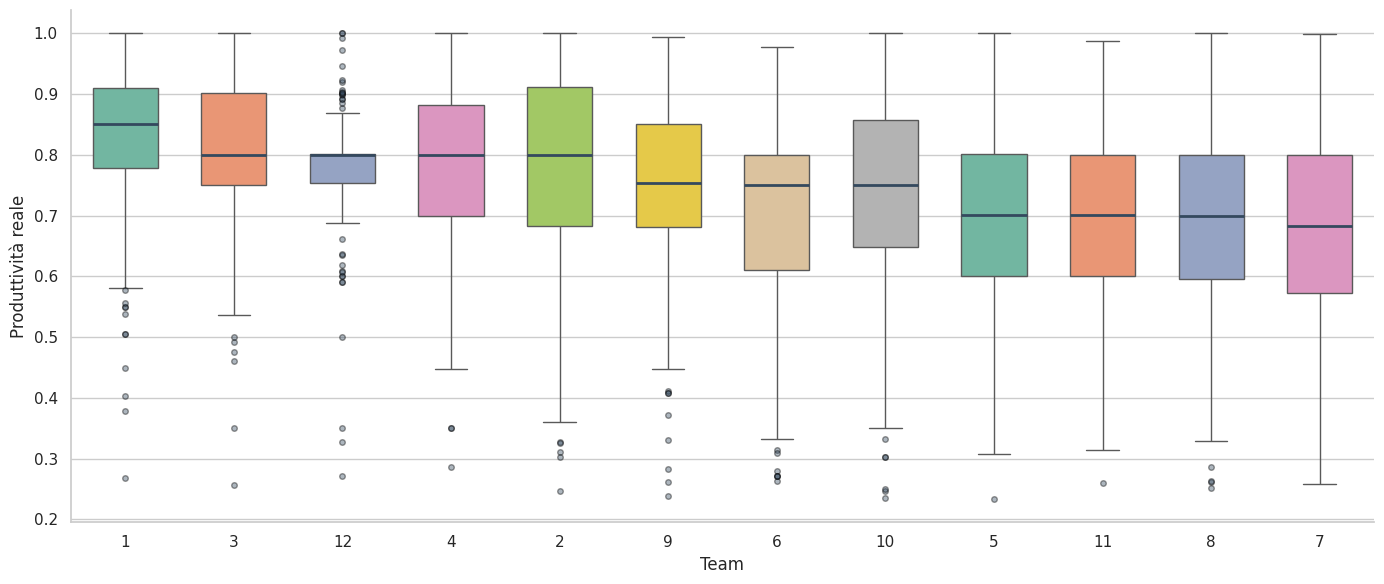

In [ ]:
# Ordina i team per mediana di produttività
team_order = (
    df.groupby('team')['actual_productivity']
    .median()
    .sort_values(ascending=False)
    .index
)

# Boxplot
plt.figure(figsize=(14, 6))
ax = sns.boxplot(
    data=df,
    x='team',
    y='actual_productivity',
    order=team_order,
    palette='Set2',  # Leggibile e più variata su molti gruppi
    width=0.6,
    medianprops=dict(color="#34495E", linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='#34495E',
                    markeredgecolor='black', markersize=4, alpha=0.4)
)

#plt.title('Distribuzione della produttività per team (ordinata per mediana)', pad=15)
plt.xlabel('Team')
plt.ylabel('Produttività reale')
plt.xticks(rotation=0, ha='center')


sns.despine()
plt.tight_layout()
plt.savefig("team_productivity_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Test di significatività tra team per actual_productivity
from scipy import stats

# Calcola gradi di libertà
bartlett_df = df['team'].nunique() - 1
kruskal_df = df['team'].nunique() - 1

# Bartlett test (test omogeneità varianze)
bartlett_stat, bartlett_p = stats.bartlett(*[
    group['actual_productivity'].values
    for _, group in df.groupby('team', observed=True)
])

# Kruskal-Wallis test (non parametrico, confronta mediane/distribuzioni)
kruskal_stat, kruskal_p = stats.kruskal(*[
    group['actual_productivity'].values
    for _, group in df.groupby('team', observed=True)
])

# Output leggibile
print("== TEST DI SIGNIFICATIVITÀ TRA TEAM ==\n")

print(f"Bartlett’s test (omogeneità varianze):")
print(f"  K²({bartlett_df}) = {bartlett_stat:.3f}, p = {bartlett_p:.6f}")
if bartlett_p < 0.05:
    print("  → Le varianze tra i team sono significativamente diverse.\n")
else:
    print("  → Nessuna evidenza di varianze differenti tra i team.\n")

print(f"Kruskal-Wallis test (distribuzioni):")
print(f"  χ²({kruskal_df}) = {kruskal_stat:.3f}, p = {kruskal_p:.2e}")
if kruskal_p < 0.05:
    print("  → Almeno un team ha una distribuzione di produttività significativamente diversa.")
else:
    print("  → Nessuna evidenza di differenze tra le distribuzioni dei team.")


== TEST DI SIGNIFICATIVITÀ TRA TEAM ==

Bartlett’s test (omogeneità varianze):
  K²(11) = 35.524, p = 0.000203
  → Le varianze tra i team sono significativamente diverse.

Kruskal-Wallis test (distribuzioni):
  χ²(11) = 124.220, p = 2.56e-21
  → Almeno un team ha una distribuzione di produttività significativamente diversa.



Lettere significative per confronto team (Dunn + Bonferroni):
Team 1: a
Team 2: a
Team 3: a
Team 4: a
Team 5: b
Team 6: 
Team 7: 
Team 8: 
Team 9: b
Team 10: b
Team 11: 
Team 12: a

Mediana produttività per fascia:
  fascia_team  actual_productivity
0        alta             0.800402
1       media             0.750651
2       bassa             0.700442


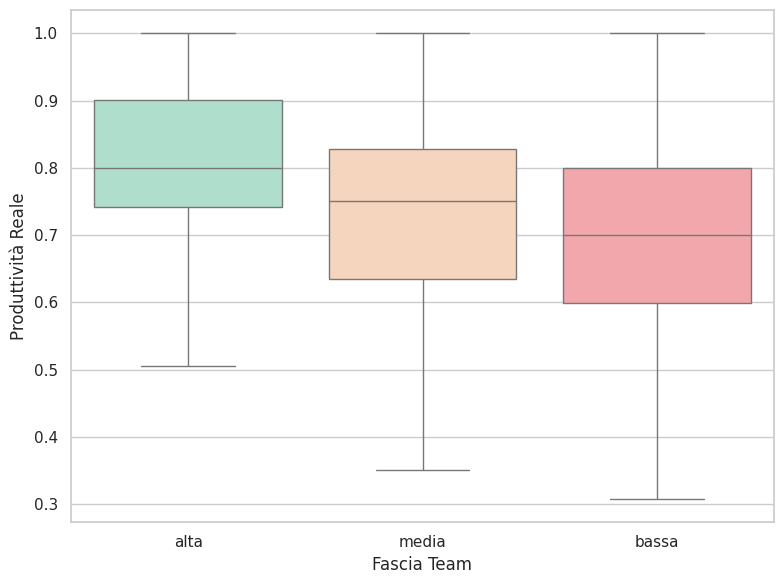

In [ ]:
# Test di Dunn con correzione Bonferroni
dunn = sp.posthoc_dunn(df, val_col='actual_productivity', group_col='team', p_adjust='bonferroni')

# Funzione per costruire lettere significative semplificate
def get_group_letters(p_matrix, alpha=0.05):
    from collections import defaultdict
    groups = list(p_matrix.index)
    letters = defaultdict(set)

    for i, g1 in enumerate(groups):
        for j, g2 in enumerate(groups):
            if i < j and p_matrix.iloc[i, j] > alpha:
                letters[g1].add(g2)
                letters[g2].add(g1)

    group_letters = {group: "" for group in groups}
    current_letter = 'a'
    assigned = set()

    while len(assigned) < len(groups):
        unassigned = [g for g in groups if g not in assigned]
        current_group = unassigned[0]
        same_letter = {current_group} | letters[current_group]
        for g in same_letter:
            if all(p_matrix.loc[g, other] > alpha for other in same_letter if other != g):
                group_letters[g] += current_letter
        assigned |= same_letter
        current_letter = chr(ord(current_letter) + 1)

    return group_letters

group_letters = get_group_letters(dunn)

# Output ordinato
print("\nLettere significative per confronto team (Dunn + Bonferroni):")
for team, letter in sorted(group_letters.items()):
    print(f"Team {team}: {letter}")

# Assegnazione manuale fasce
df['fascia_team'] = np.select(
    [
        df['team'].isin([1, 2, 3, 4, 12]),
        df['team'].isin([5, 7, 8, 11]),
        df['team'].isin([6, 9, 10])
    ],
    ['alta_produttività', 'bassa_produttività', 'media_produttività'],
    default=''
)

# Rinomina e ordina fasce
df['fascia_team'] = df['fascia_team'].replace({
    'alta_produttività': 'alta',
    'bassa_produttività': 'bassa',
    'media_produttività': 'media'
})
df['fascia_team'] = pd.Categorical(df['fascia_team'], categories=['alta', 'media', 'bassa'], ordered=True)

# Mediana per fascia
print("\nMediana produttività per fascia:")
print(df.groupby('fascia_team')['actual_productivity'].median().reset_index())

# Boxplot finale
palette = {
    'alta':  '#A8E6CF',  # verde menta pastello
    'media': '#FFD3B5',  # pesca chiaro pastello
    'bassa': '#FF9AA2'   # rosa corallo pastello
}

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='fascia_team', y='actual_productivity', hue='fascia_team',
            palette=palette, showfliers=False)
plt.xlabel("Fascia Team")
plt.ylabel("Produttività Reale")
#plt.titlee("Produttività per fascia di team", pad=15)
plt.legend().remove()
plt.tight_layout()
plt.savefig("fascia_team_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


## EDA: Number of style change

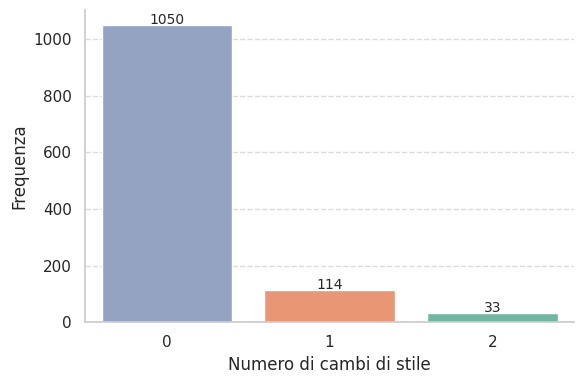

In [ ]:
# Converte in categoriale con livelli ordinati
df['no_of_style_change'] = pd.Categorical(df['no_of_style_change'], categories=[0, 1, 2], ordered=True)

# Conteggio osservazioni
counts = df['no_of_style_change'].value_counts().sort_index().reset_index()
counts.columns = ['no_of_style_change', 'n']

# Barplot
plt.figure(figsize=(6, 4))
palette = ['#8da0cb', '#fc8d62', '#66c2a5']  # Colori leggibili e coerenti
ax = sns.barplot(data=counts, x='no_of_style_change', y='n', palette=palette)

# Etichette
for i, row in counts.iterrows():
    ax.text(i, row.n + 2, str(row.n), ha='center', fontsize=10)

#plt.title("Frequenza per numero di cambi di stile")
plt.xlabel("Numero di cambi di stile")
plt.ylabel("Frequenza")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()


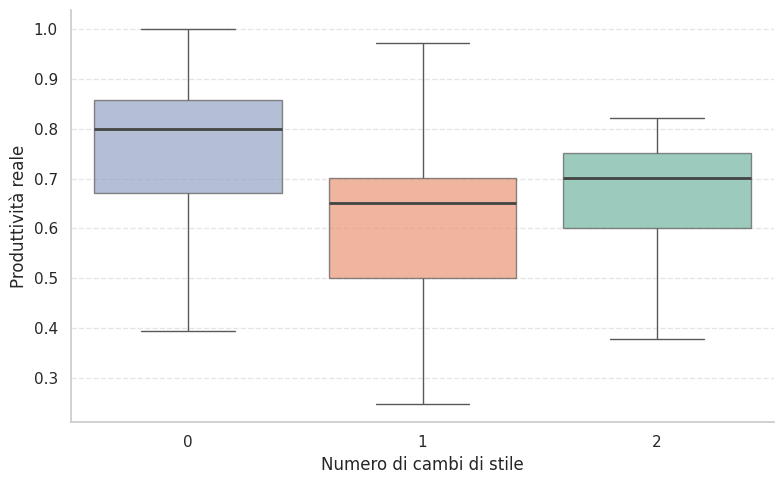

In [ ]:
# Boxplot migliorato
plt.figure(figsize=(8, 5))

palette = ['#8da0cb', '#fc8d62', '#66c2a5']

sns.boxplot(
    data=df,
    x='no_of_style_change',
    y='actual_productivity',
    palette=palette,
    showfliers=False,
    boxprops=dict(alpha=0.7),
    medianprops=dict(color='#444', linewidth=2),
    flierprops=dict(markerfacecolor='red', markeredgecolor='black', markersize=3)
)

plt.xlabel("Numero di cambi di stile")
plt.ylabel("Produttività reale")
#plt.title("Distribuzione della produttività per numero di cambi di stile", pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.savefig("style_change_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Bartlett test
bartlett_stat, bartlett_p = stats.bartlett(*[
    g['actual_productivity'].values for _, g in df.groupby('no_of_style_change', observed=True)
])
bartlett_df = df['no_of_style_change'].nunique() - 1

# Kruskal-Wallis test (non parametrico)
kruskal_stat, kruskal_p = stats.kruskal(*[
    g['actual_productivity'].values for _, g in df.groupby('no_of_style_change', observed=True)
])
kruskal_df = bartlett_df

# Output
print("== TEST DI SIGNIFICATIVITÀ PER CAMBI DI STILE ==\n")

print(f"Bartlett’s test (omogeneità varianze):")
print(f"  K²({bartlett_df}) = {bartlett_stat:.3f}, p = {bartlett_p:.6f}")
if bartlett_p < 0.05:
    print("  → Varianze significativamente diverse.\n")
else:
    print("  → Nessuna evidenza di varianze diverse.\n")



== TEST DI SIGNIFICATIVITÀ PER CAMBI DI STILE ==

Bartlett’s test (omogeneità varianze):
  K²(2) = 5.650, p = 0.059317
  → Nessuna evidenza di varianze diverse.




== ANOVA ==
                        sum_sq      df       F  PR(>F)
C(no_of_style_change)   2.0436     2.0  35.979     0.0
Residual               33.9091  1194.0     NaN     NaN

== Tukey HSD ==
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1  -0.1347    0.0 -0.1737 -0.0957   True
     0      2  -0.0878 0.0092 -0.1577 -0.0179   True
     1      2   0.0469 0.3372 -0.0313  0.1251  False
----------------------------------------------------


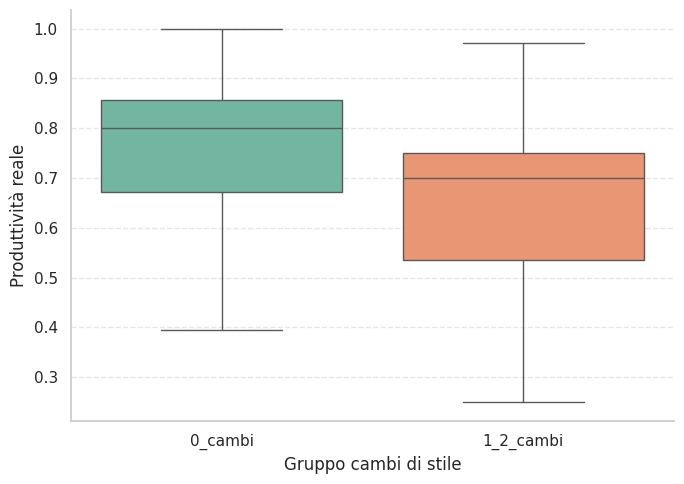

In [ ]:
# ANOVA
model = smf.ols('actual_productivity ~ C(no_of_style_change)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\n== ANOVA ==")
print(anova_table.round(4))

# Tukey HSD post-hoc
print("\n== Tukey HSD ==")
tukey = pairwise_tukeyhsd(
    endog=df['actual_productivity'],
    groups=df['no_of_style_change'],
    alpha=0.05
)
print(tukey)

# Aggregazione 1 e 2 cambi
df['gruppi_change'] = df['no_of_style_change'].map({
    0: '0_cambi',
    1: '1_2_cambi',
    2: '1_2_cambi'
})
df['gruppi_change'] = pd.Categorical(df['gruppi_change'], categories=['0_cambi', '1_2_cambi'], ordered=True)

# Boxplot
plt.figure(figsize=(7, 5))
palette = {'0_cambi': '#66c2a5', '1_2_cambi': '#fc8d62'}
sns.boxplot(data=df, x='gruppi_change', y='actual_productivity',
            hue='gruppi_change', palette=palette, showfliers=False)

#plt.title("Produttività reale per gruppo di cambi di stile", pad=15)
plt.xlabel("Gruppo cambi di stile")
plt.ylabel("Produttività reale")
plt.legend().remove()
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.savefig("gruppi_change_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


## Standardizzazione e Matrice di Correlazione

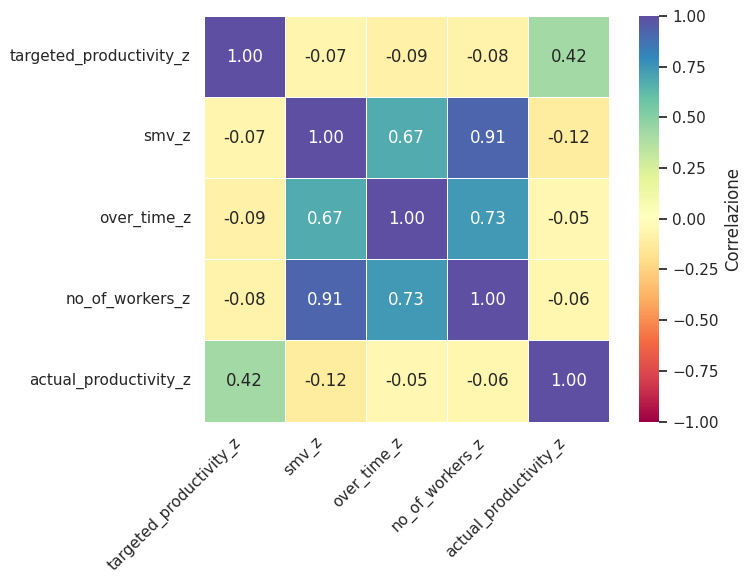

In [ ]:
# Standardizzazione delle variabili
vars_to_scale = ['targeted_productivity', 'smv', 'over_time', 'no_of_workers', 'actual_productivity']
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[vars_to_scale])

df_z = pd.DataFrame(scaled_values, columns=[f"{col}_z" for col in vars_to_scale])
df = pd.concat([df, df_z], axis=1)

# Matrice di correlazione
df_corr = df[df_z.columns]
cor_matrix = df_corr.corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cor_matrix,
    annot=True,
    fmt=".2f",
    cmap="Spectral",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlazione'}
)

#plt.title("Matrice di Correlazione (Z-score)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap_zscore.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# Modelli Implementati

## Random Forest

 R²  : 0.4390
 RMSE: 0.7530
 MAE : 0.5343

Importanza delle variabili:
                        Feature  Importance
0       targeted_productivity_z    0.335359
1                         smv_z    0.146600
3               no_of_workers_z    0.127976
2                   over_time_z    0.081076
12            fascia_team_bassa    0.069330
13      gruppi_change_1_2_cambi    0.069113
9   has_incentive_Con_incentivo    0.064556
10            department_sweing    0.030991
11            fascia_team_media    0.028386
14               month_February    0.015942
15                  month_March    0.010314
6                  day_Thursday    0.007816
7                  day_Saturday    0.003809
4                   day_Tuesday    0.003092
5                 day_Wednesday    0.003029
8                    day_Sunday    0.002610


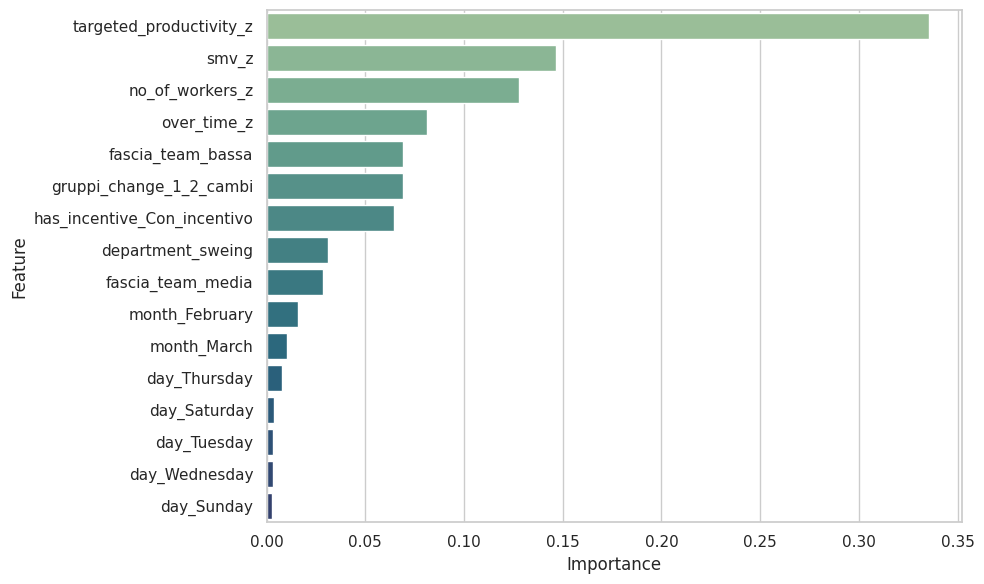

In [ ]:
# Selezione delle variabili
df_nuovo = df[
    [
        'actual_productivity_z',
        'targeted_productivity_z',
        'smv_z',
        'over_time_z',
        'no_of_workers_z',
        'day',
        'has_incentive',
        'department',
        'fascia_team',
        'gruppi_change',
        'month'
    ]
]

# Train/test split
train_data, test_data = train_test_split(df_nuovo, test_size=0.2, random_state = 123)

# Separazione target e features
y_train = train_data['actual_productivity_z']
y_test = test_data['actual_productivity_z']
X_train = train_data.drop(columns='actual_productivity_z')
X_test = test_data.drop(columns='actual_productivity_z')

# One-hot encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Allineamento colonne
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Random Forest con parametri custom
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_features=3,
    min_samples_leaf=10,
    max_leaf_nodes=20,
    n_jobs=-1,
    random_state=123
)
rf_model.fit(X_train, y_train)

# Predizione e metriche
predictions = rf_model.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train, predictions))
mae = mean_absolute_error(y_train, predictions)
rsq = r2_score(y_train, predictions)

print(f" R²  : {rsq:.4f}")
print(f" RMSE: {rmse:.4f}")
print(f" MAE : {mae:.4f}")

# Feature importance
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nImportanza delle variabili:")
print(importance_df)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='crest'
)
#plt.title('Importanza delle Variabili - Random Forest')
plt.tight_layout()
plt.savefig("random_forest_importance.png", dpi=300, bbox_inches='tight')
plt.show()


## Random Forest con Feature più importanti

In [ ]:
# Nuovo DataFrame con variabili selezionate
df_nuovo_2 = df_nuovo[
    ['targeted_productivity_z', 'fascia_team', 'no_of_workers_z',
     'smv_z', 'has_incentive', 'gruppi_change', 'actual_productivity_z', 'over_time_z']
]

# Separare variabili indipendenti e target
X_sel = df_nuovo_2.drop(columns='actual_productivity_z')
y_sel = df_nuovo_2['actual_productivity_z']

# One-hot encoding
X_sel = pd.get_dummies(X_sel, drop_first=True)

# Train/test split
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_sel, y_sel, test_size=0.2, random_state=123
)

# Modello Random Forest
rf_selected = RandomForestRegressor(
    n_estimators=200,
    max_features=3,
    min_samples_leaf=10,
    max_leaf_nodes=20,
    n_jobs=-1,
    random_state = 123
)
rf_selected.fit(X_train_sel, y_train_sel)

# Fit e predizione
rf_selected.fit(X_train_sel, y_train_sel)
rf_pred = rf_selected.predict(X_train_sel)

# Valutazione
rmse = np.sqrt(mean_squared_error(y_train_sel, rf_pred))
mae = mean_absolute_error(y_train_sel, rf_pred)
rsq = r2_score(y_train_sel, rf_pred)

print(f" R²  : {rsq:.4f}")
print(f" RMSE: {rmse:.4f}")
print(f" MAE : {mae:.4f}")


 R²  : 0.4818
 RMSE: 0.7237
 MAE : 0.5010


## Cross Validation

In [ ]:
# Funzione RMSE personalizzata
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Scorer multipli
scorers = {
    'rmse': make_scorer(rmse_score, greater_is_better=False),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'r2': make_scorer(r2_score)
}

# Modello base
rf_model = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=10,
    max_leaf_nodes=20,
    n_jobs=-1,
    random_state = 123
)

# Griglia dei parametri
param_grid = {'max_features': [2, 5, 8]}

# Cross-validation setup
cv = KFold(n_splits=10, shuffle=True, random_state = 123)

# GridSearch
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring=scorers,
    refit='rmse',
    cv=cv,
    return_train_score=True
)

# Fit del modello
grid_search.fit(X_train_sel, y_train_sel)

# Output
print("=== Risultati Cross-Validation (10-fold) Random Forest con tuning ===")
for i in range(len(grid_search.cv_results_['params'])):
    mtry = grid_search.cv_results_['param_max_features'][i]
    r2 = grid_search.cv_results_['mean_test_r2'][i]
    r2_sd = grid_search.cv_results_['std_test_r2'][i]
    rmse = -grid_search.cv_results_['mean_test_rmse'][i]
    rmse_sd = grid_search.cv_results_['std_test_rmse'][i]
    mae = -grid_search.cv_results_['mean_test_mae'][i]
    mae_sd = grid_search.cv_results_['std_test_mae'][i]

    print(f"mtry = {mtry} → R²: {r2:.4f} (± {r2_sd:.4f}), RMSE: {rmse:.4f} (± {rmse_sd:.4f}), MAE: {mae:.4f} (± {mae_sd:.4f})")


=== Risultati Cross-Validation (10-fold) Random Forest con tuning ===
mtry = 2 → R²: 0.3806 (± 0.0858), RMSE: 0.7754 (± 0.0821), MAE: 0.5448 (± 0.0526)
mtry = 5 → R²: 0.4129 (± 0.1063), RMSE: 0.7528 (± 0.0888), MAE: 0.5130 (± 0.0498)
mtry = 8 → R²: 0.4057 (± 0.1159), RMSE: 0.7565 (± 0.0936), MAE: 0.5144 (± 0.0529)


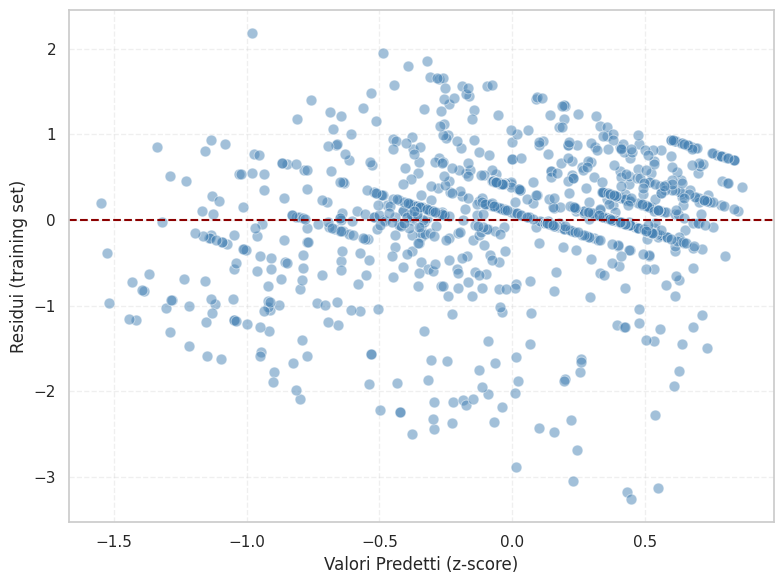

In [ ]:
from sklearn.model_selection import cross_val_predict

# Calcolo delle predizioni nel training set tramite cross-validation (simula predizioni mai viste)
rf_pred_train_cv = cross_val_predict(rf_selected, X_train_sel, y_train_sel, cv=10)

# Calcolo dei residui sul TRAINING (coerente per outlier detection)
residui = y_train_sel - rf_pred_train_cv

# DataFrame per il plot
resid_df = pd.DataFrame({
    'Predetto': rf_pred_train_cv,
    'Residuo': residui
})

# Plot dei residui
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

sns.scatterplot(
    data=resid_df,
    x='Predetto',
    y='Residuo',
    alpha=0.5,
    s=60,
    color='steelblue',
    edgecolor='white'
)

plt.axhline(0, linestyle='--', color='darkred', linewidth=1.5)
plt.xlabel('Valori Predetti (z-score)', fontsize=12)
plt.ylabel('Residui (training set)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("rf_residuals_training_plot.png", dpi=300, bbox_inches='tight')
plt.show()


## Controllo valori anomali

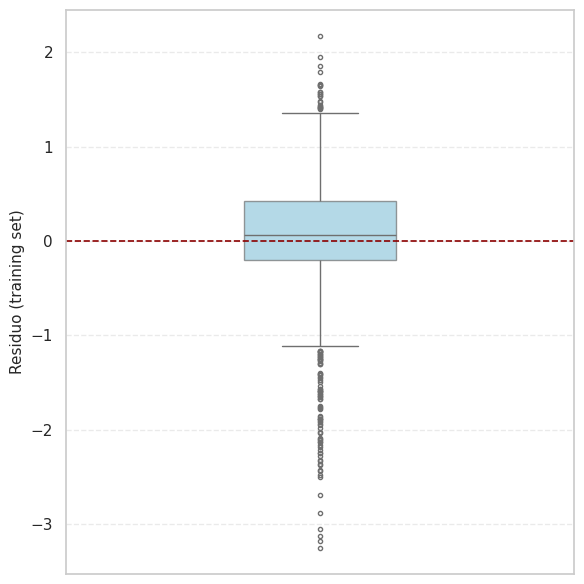

In [ ]:
# Ricostruisco il DataFrame solo sul training
df_residui = X_train_sel.copy()
df_residui['actual_productivity_z'] = y_train_sel
df_residui['residuo'] = residui  # residui ottenuti da cross_val_predict

# Boxplot dei residui
plt.figure(figsize=(6, 6))
sns.set_style("whitegrid")

sns.boxplot(
    y='residuo',
    data=df_residui,
    color='skyblue',
    width=0.3,
    fliersize=3,
    boxprops=dict(alpha=0.7)
)

plt.axhline(0, color='darkred', linestyle='--', linewidth=1.2)
plt.ylabel("Residuo (training set)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("rf_residuals_boxplot_training.png", dpi=300, bbox_inches='tight')
plt.show()

Numero di outlier nei residui: 105


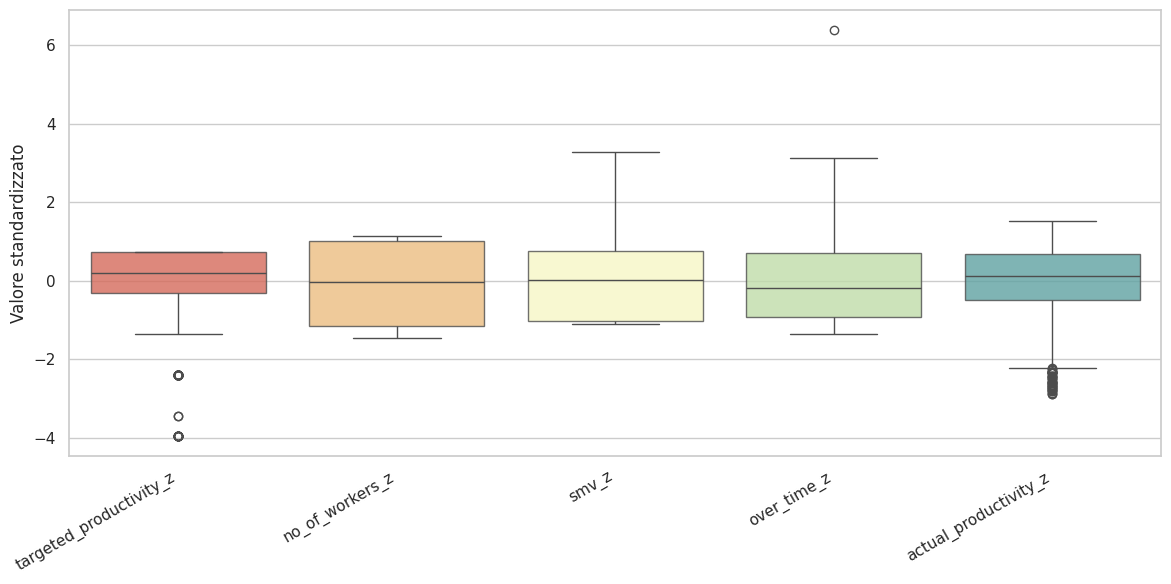

In [ ]:
# Calcolo soglie IQR per i residui (sul training set)
Q1 = df_residui['residuo'].quantile(0.25)
Q3 = df_residui['residuo'].quantile(0.75)
IQR = Q3 - Q1

soglia_inf = Q1 - 1.5 * IQR
soglia_sup = Q3 + 1.5 * IQR

# Outlier nei residui (sul training)
outlier_residui = df_residui[
    (df_residui['residuo'] < soglia_inf) | (df_residui['residuo'] > soglia_sup)
]

print(f"Numero di outlier nei residui: {outlier_residui.shape[0]}")

# === Boxplot delle variabili numeriche ===

# Ricostruzione training set numerico (X + y)
df_train_full = X_train_sel.copy()
df_train_full['actual_productivity_z'] = y_train_sel

# Solo variabili numeriche
df_long = df_train_full.select_dtypes(include=[np.number]).melt(
    var_name="Variabile", value_name="Valore"
)

# Boxplot multipli (variabili numeriche standardizzate)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.boxplot(
    x='Variabile',
    y='Valore',
    data=df_long,
    palette='Spectral',
    boxprops={'alpha': 0.8}
)

plt.ylabel("Valore standardizzato", fontsize=12)
plt.xlabel("")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("zscore_variables_boxplot_training.png", dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
# seed
np.random.seed(123)

# Filtro: rimuovo outlier dal training set (già fatto precedentemente)
df_clean = df_residui[
    (df_residui['residuo'] >= soglia_inf) & (df_residui['residuo'] <= soglia_sup)
].drop(columns='residuo')

# Nuovo X e y
X_clean = df_clean.drop(columns='actual_productivity_z')
y_clean = df_clean['actual_productivity_z']
X_clean = pd.get_dummies(X_clean, drop_first=True)

# Train/test split sui dati puliti (internamente al training)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=123
)

# Modello Random Forest sui dati puliti
rf_clean = RandomForestRegressor(
    n_estimators=200,
    max_features=3,
    min_samples_leaf=10,
    max_leaf_nodes=20,
    n_jobs=-1,
    random_state=123
)
rf_clean.fit(X_train_clean, y_train_clean)
rf_clean_pred = rf_clean.predict(X_train_clean)


def evaluate_model(actual, predicted):
    return pd.DataFrame({
        'R2': [r2_score(actual, predicted)],
        'RMSE': [np.sqrt(mean_squared_error(actual, predicted))],
        'MAE': [mean_absolute_error(actual, predicted)]
    })

# Calcolo metriche per Random Forest su dati puliti
rf_metrics = evaluate_model(y_train_clean, rf_clean_pred)

# Stampa delle metriche
print("=== Performance Random Forest su dati puliti ===")
print(f"R²:   {rf_metrics['R2'].values[0]:.3f}")
print(f"RMSE: {rf_metrics['RMSE'].values[0]:.3f}")
print(f"MAE:  {rf_metrics['MAE'].values[0]:.3f}")


=== Performance Random Forest su dati puliti ===
R²:   0.679
RMSE: 0.448
MAE:  0.324


## Cross Validation (Su dataset PULITO)

In [ ]:
# seed
np.random.seed(123)

# Definizione modello Random Forest
rf_cv_model = RandomForestRegressor(
    n_estimators=200,
    max_features=3,
    min_samples_leaf=10,
    max_leaf_nodes=20,
    n_jobs=-1,
    random_state=123
    )

# Setup della cross-validation
cv = KFold(n_splits=10, shuffle=True, random_state = 123)

# Calcolo delle metriche
r2_scores = cross_val_score(rf_cv_model, X_train_clean, y_train_clean, cv=cv, scoring='r2')
mae_scores = -cross_val_score(rf_cv_model, X_train_clean, y_train_clean, cv=cv, scoring='neg_mean_absolute_error')
rmse_scores = -cross_val_score(rf_cv_model, X_train_clean, y_train_clean, cv=cv, scoring='neg_root_mean_squared_error')

# Media e deviazione standard
r2_mean, r2_std = r2_scores.mean(), r2_scores.std()
mae_mean, mae_std = mae_scores.mean(), mae_scores.std()
rmse_mean, rmse_std = rmse_scores.mean(), rmse_scores.std()

# Output formattato
print("=== Risultati Cross-Validation (10-fold) RF - Pulita ===")
print(f"R2 medio:  {r2_mean:.4f} (± {r2_std:.4f})")
print(f"MAE medio: {mae_mean:.4f} (± {mae_std:.4f})")
print(f"RMSE medio: {rmse_mean:.4f} (± {rmse_std:.4f})")

=== Risultati Cross-Validation (10-fold) RF - Pulita ===
R2 medio:  0.6078 (± 0.0874)
MAE medio: 0.3554 (± 0.0360)
RMSE medio: 0.4865 (± 0.0505)


     Modello     R2   RMSE    MAE
0  Originale  0.439  0.753  0.534
0    Ridotto  0.482  0.724  0.501
0     Pulito  0.679  0.448  0.324


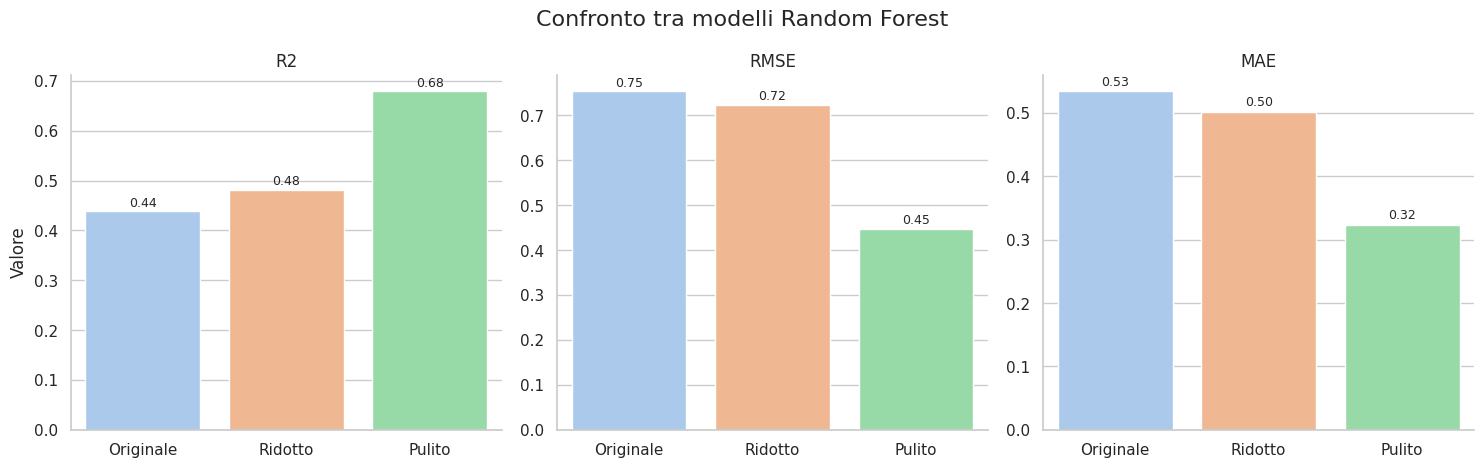

In [ ]:
# Originale (tutto il dataset iniziale)
rf_full_perf = evaluate_model(y_train, predictions)

# Ridotto (feature più importanti)
rf_reduced_perf = evaluate_model(y_train_sel, rf_pred) #rf_selected.predict(X_sel))

# Pulito (dopo rimozione outlier sui residui)
rf_clean_perf   = evaluate_model(y_train_clean, rf_clean_pred)

# Unione delle performance
df_metriche = pd.concat(
    [rf_full_perf, rf_reduced_perf, rf_clean_perf],
    keys=['Originale', 'Ridotto', 'Pulito'],
    names=['Modello']
).reset_index(level='Modello')

# Arrotondamento e stampa
df_metriche = df_metriche.round(3)
print(df_metriche)

# Conversione in formato long per il plot
df_long = df_metriche.melt(id_vars='Modello', var_name='Metrica', value_name='Valore')
df_long['Metrica'] = pd.Categorical(df_long['Metrica'], categories=['R2','RMSE','MAE'], ordered=True)

# Plot a barre

g = sns.catplot(
    data=df_long,
    kind='bar',
    x='Modello',
    y='Valore',
    col='Metrica',
    col_wrap=3,
    palette='pastel',
    sharey=False
)

for ax, met in zip(g.axes.flat, ['R2', 'RMSE', 'MAE']):
    ax.set_xlabel("")  # rimuove label asse x
    ax.set_title(met)
    for p in ax.patches:
        h = p.get_height()
        ax.text(p.get_x() + p.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', fontsize=9)

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Confronto tra modelli Random Forest", fontsize=16)
plt.show()



## XGBoost

In [ ]:
# seed
np.random.seed(123)

# Preprocessing
X = pd.get_dummies(df_clean.drop(columns='actual_productivity_z'), drop_first=True)
y = df_clean['actual_productivity_z']

# Modello XGBoost
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    verbosity=0,
    random_state=123
)

# Split per XGBoost
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X, y, test_size=0.2, random_state=123)

# Fit & Predict
xgb_model.fit(X_train_xgb, y_train_xgb)
xgb_pred = xgb_model.predict(X_train_xgb)

# Valutazione
xgb_perf = pd.DataFrame({
    'R2': [r2_score(y_train_xgb, xgb_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_train_xgb, xgb_pred))],
    'MAE': [mean_absolute_error(y_train_xgb, xgb_pred)]
}).round(3)

print("Performance del modello XGBoost:")
print(xgb_perf)

Performance del modello XGBoost:
      R2  RMSE    MAE
0  0.836  0.32  0.223


In [ ]:
# seed
np.random.seed(123)

# Definizione del modello XGBoost per CV
xgb_cv_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    gamma=0,
    colsample_bytree=0.8,
    min_child_weight=1,
    subsample=0.8,
    objective="reg:squarederror",
    verbosity=0,
    random_state=123
)

# Cross-validation
cv = KFold(n_splits=10, shuffle=True, random_state=123)

# Calcolo delle metriche con scoring negativo (per RMSE e MAE)
rmse_scores = -cross_val_score(xgb_cv_model, X_train_xgb, y_train_xgb, cv=cv, scoring='neg_root_mean_squared_error')
mae_scores = -cross_val_score(xgb_cv_model, X_train_xgb, y_train_xgb, cv=cv, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(xgb_cv_model, X_train_xgb, y_train_xgb, cv=cv, scoring='r2')

# Calcolo media e std
rmse_mean, rmse_std = rmse_scores.mean(), rmse_scores.std()
mae_mean, mae_std = mae_scores.mean(), mae_scores.std()
r2_mean, r2_std = r2_scores.mean(), r2_scores.std()

# Tabella
print("=== Risultati Cross-Validation (10-fold) XGBoost ===")
print(f"R2 medio:  {r2_mean:.4f} (± {r2_std:.4f})")
print(f"MAE medio: {mae_mean:.4f} (± {mae_std:.4f})")
print(f"RMSE medio: {rmse_mean:.4f} (± {rmse_std:.4f})")


=== Risultati Cross-Validation (10-fold) XGBoost ===
R2 medio:  0.6662 (± 0.1068)
MAE medio: 0.3154 (± 0.0358)
RMSE medio: 0.4424 (± 0.0496)


Importanza variabili (XGBoost - Gain):


,Feature,Gain
7,gruppi_change_1_2_cambi,3.371002
0,targeted_productivity_z,3.133891
5,fascia_team_bassa,1.349136
4,fascia_team_media,1.287913
6,has_incentive_Con_incentivo,1.027907
1,no_of_workers_z,0.945129
2,smv_z,0.874734
3,over_time_z,0.498794


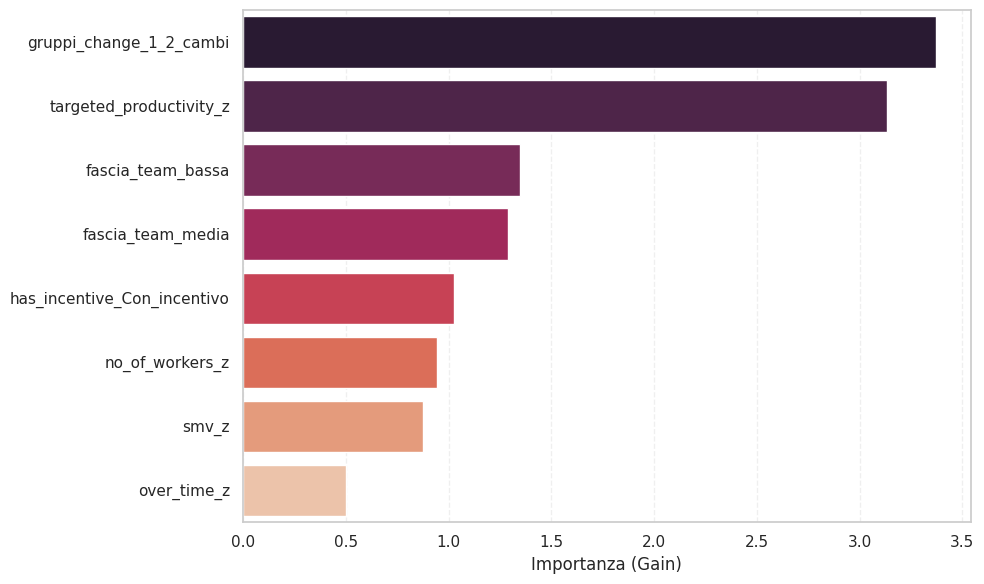

In [ ]:
# Estrai importanza a livello di gain
importance_matrix = xgb_model.get_booster().get_score(importance_type='gain')

# Costruisci DataFrame e ordina dal più importante al meno importante
importance_df = (
    pd.DataFrame.from_dict(importance_matrix, orient='index', columns=['Gain'])
      .rename_axis("Feature")
      .reset_index()
      .sort_values(by="Gain", ascending=False)  # <-- descending
)

# Stampa tabella (ordinata)
print("Importanza variabili (XGBoost - Gain):")
display(importance_df)

# Plot orizzontale con le più importanti in alto
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    y="Feature",
    x="Gain",
    palette="rocket",
    order=importance_df['Feature']  # assicura l'ordine corrente
)

plt.xlabel("Importanza (Gain)", fontsize=12)
plt.ylabel("")
#plt.title("Importanza delle variabili - XGBoost (Gain)", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

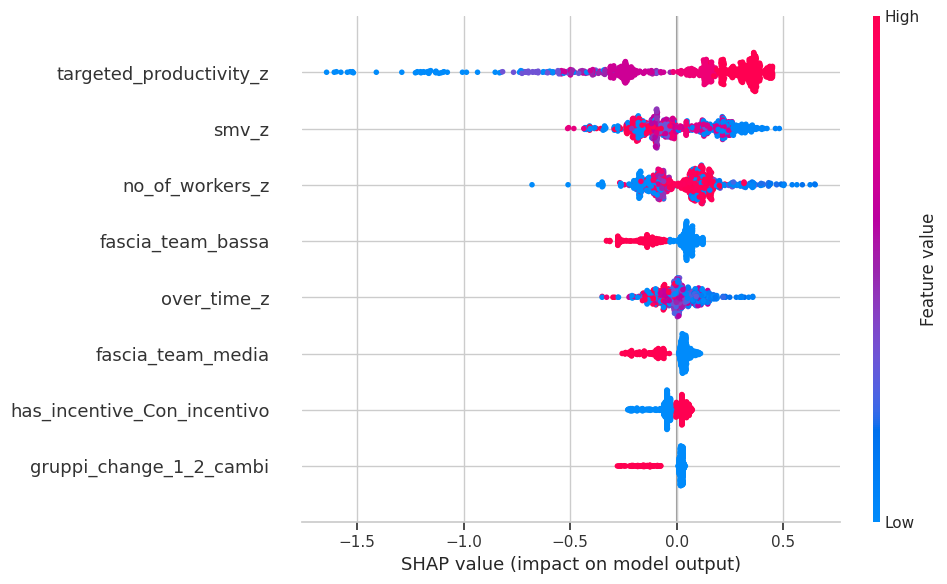

In [ ]:
# Calcolo dei valori SHAP (SHapley Additive exPlanations)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

# Summary plot (scatter style)
shap.summary_plot(
    shap_values, X,
    plot_type="dot",
    show=True,
    plot_size=(10, 6)
)


## SVR

In [ ]:
# Preprocessing
X = pd.get_dummies(df_clean.drop(columns='actual_productivity_z'), drop_first=True)
X = X.astype(float).replace([np.inf, -np.inf], np.nan).dropna(axis=1)
y = df_clean['actual_productivity_z']

# Selezione variabili numeriche
numeric_vars =['targeted_productivity_z',
               'no_of_workers_z',
               'smv_z',
               'over_time_z']

X_vif = df_clean[numeric_vars].copy()
X_vif = sm.add_constant(X_vif)

# Calcolo VIF
vif_df = pd.DataFrame({
    "Feature": X_vif.columns[1:],
    "VIF": [variance_inflation_factor(X_vif.values, i + 1) for i in range (len(X_vif.columns) - 1)]
})

print("=== VIF - Verifica multicollinearità ===")
print(vif_df.sort_values(by='VIF'))

# Train/test split
X_train_svr, X_test_svr, y_train_svr, y_test_svr = train_test_split(X, y, test_size=0.2, random_state=123)

# SVR con GridSearch
svr = SVR(kernel='rbf')
param_grid = {'C': [0.1, 1, 10], 'epsilon': [0.01, 0.1, 0.5], 'gamma': ['scale', 'auto']}
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_svr, y_train_svr)

best_svr = grid_search.best_estimator_
y_pred_svr = best_svr.predict(X_train_svr)

# Metriche
r2_svr = r2_score(y_train_svr, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_train_svr, y_pred_svr))
mae_svr = mean_absolute_error(y_train_svr, y_pred_svr)

print("\n=== Performance SVR ===")
print(f"R²:   {r2_svr:.3f}")
print(f"RMSE: {rmse_svr:.3f}")
print(f"MAE:  {mae_svr:.3f}")
print("Migliori parametri trovati:", grid_search.best_params_)


=== VIF - Verifica multicollinearità ===
                   Feature       VIF
0  targeted_productivity_z  1.013165
3              over_time_z  2.176532
2                    smv_z  6.271605
1          no_of_workers_z  7.348062

=== Performance SVR ===
R²:   0.683
RMSE: 0.445
MAE:  0.274
Migliori parametri trovati: {'C': 10, 'epsilon': 0.01, 'gamma': 'auto'}


In [ ]:
# PCA dopo split
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_svr)
X_test_pca = pca.transform(X_test_svr)

# Stampa parametri PCA
n_comp = pca.n_components_
var_exp = pca.explained_variance_ratio_.round(3)
cum_var = np.cumsum(var_exp).round(3)

print("\n=== PCA Summary ===")
print(f"Numero componenti: {n_comp}")
print("Varianza spiegata per componente:", var_exp)
print("Varianza spiegata cumulativa:", cum_var)

# === SVR con GridSearch su PCA ===
svr_pca = SVR(kernel='rbf')
grid_search_pca = GridSearchCV(svr_pca, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search_pca.fit(X_train_pca, y_train_svr)

best_svr_pca = grid_search_pca.best_estimator_
y_pred_pca = best_svr_pca.predict(X_train_pca)

# === Metriche ===
r2_pca = r2_score(y_train_svr, y_pred_pca)
rmse_pca = np.sqrt(mean_squared_error(y_train_svr, y_pred_pca))
mae_pca = mean_absolute_error(y_train_svr, y_pred_pca)

print("\n=== Performance SVR con PCA ===")
print(f"R²:   {r2_pca:.3f}")
print(f"RMSE: {rmse_pca:.3f}")
print(f"MAE:  {mae_pca:.3f}")
print("Migliori parametri trovati:", grid_search_pca.best_params_)



=== PCA Summary ===
Numero componenti: 6
Varianza spiegata per componente: [0.572 0.215 0.078 0.058 0.027 0.025]
Varianza spiegata cumulativa: [0.572 0.787 0.865 0.923 0.95  0.975]

=== Performance SVR con PCA ===
R²:   0.676
RMSE: 0.450
MAE:  0.280
Migliori parametri trovati: {'C': 10, 'epsilon': 0.01, 'gamma': 'auto'}


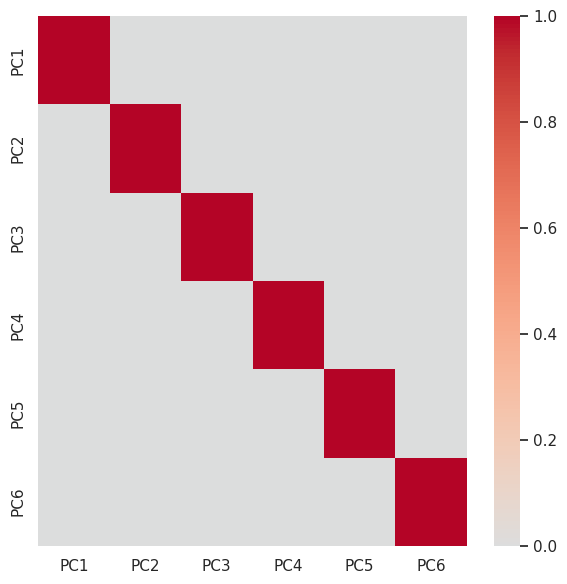

In [ ]:
# Heatmap di correlazione fra componenti PCA (usando i dati di train)
corr_pca = np.corrcoef(X_train_pca.T)
plt.figure(figsize=(6,6))
sns.heatmap(corr_pca, annot=False, cmap='coolwarm', center=0,
            xticklabels=[f'PC{i+1}' for i in range(X_train_pca.shape[1])],
            yticklabels=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
#plt.title("Correlazione tra componenti PCA (train set)")
plt.tight_layout()
plt.show()


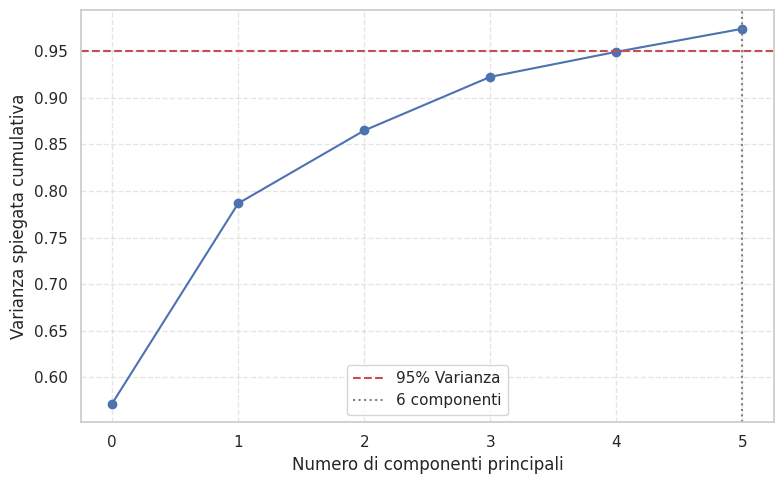

Componenti necessarie per il 95% della varianza: 6


In [ ]:
# Grafico della varianza spiegata cumulativa
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Varianza')
plt.axvline(x=pca.n_components_ - 1, color='gray', linestyle=':', label=f'{pca.n_components_} componenti')
plt.xlabel('Numero di componenti principali')
plt.ylabel('Varianza spiegata cumulativa')
#plt.title('PCA - Varianza spiegata cumulativa')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Componenti necessarie per il 95% della varianza: {pca.n_components_}")

In [ ]:
# Creazione DataFrame con loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# Ordinamento dei loadings per componente (valori assoluti maggiori)
for pc in loadings.columns:
    print(f"\n--- Loadings per {pc} (valori assoluti più alti) ---")
    display(loadings[pc].abs().sort_values(ascending=False).head(10))

# Se vuoi vedere l'intera tabella:
display(loadings.round(3))



--- Loadings per PC1 (valori assoluti più alti) ---


,PC1
no_of_workers_z,0.589740
smv_z,0.558976
over_time_z,0.518830
has_incentive_Con_incentivo,0.231001
targeted_productivity_z,0.115725
gruppi_change_1_2_cambi,0.058633
fascia_team_bassa,0.014116
fascia_team_media,0.013325



--- Loadings per PC2 (valori assoluti più alti) ---


,PC2
targeted_productivity_z,0.974840
fascia_team_bassa,0.129024
has_incentive_Con_incentivo,0.104658
gruppi_change_1_2_cambi,0.084168
fascia_team_media,0.070634
smv_z,0.062190
no_of_workers_z,0.059000
over_time_z,0.051611



--- Loadings per PC3 (valori assoluti più alti) ---


...


--- Loadings per PC5 (valori assoluti più alti) ---


,PC5
has_incentive_Con_incentivo,0.523294
fascia_team_media,0.507742
fascia_team_bassa,0.483262
gruppi_change_1_2_cambi,0.331885
smv_z,0.287477
no_of_workers_z,0.175707
over_time_z,0.095605
targeted_productivity_z,0.044896



--- Loadings per PC6 (valori assoluti più alti) ---


,PC6
fascia_team_media,0.590322
has_incentive_Con_incentivo,0.544084
fascia_team_bassa,0.403636
smv_z,0.295016
gruppi_change_1_2_cambi,0.255322
no_of_workers_z,0.158360
over_time_z,0.096847
targeted_productivity_z,0.076744


,PC1,PC2,PC3,PC4,PC5,PC6
targeted_productivity_z,-0.116,0.975,-0.018,0.154,-0.045,0.077
no_of_workers_z,0.590,0.059,-0.277,0.039,0.176,-0.158
smv_z,0.559,0.062,-0.407,-0.035,-0.287,0.295
over_time_z,0.519,0.052,0.828,0.045,-0.096,0.097
fascia_team_media,-0.013,0.071,0.028,-0.620,0.508,0.590
fascia_team_bassa,0.014,-0.129,-0.049,0.757,0.483,0.404
has_incentive_Con_incentivo,0.231,0.105,-0.112,-0.118,0.523,-0.544
gruppi_change_1_2_cambi,0.059,-0.084,-0.235,-0.015,-0.332,0.255


In [ ]:
# seed
np.random.seed(123)

# Pipeline PCA + SVR
pipeline = Pipeline([
    ('pca', PCA(n_components=0.95)),
    ('svr', SVR(kernel='rbf'))
])

# Griglia iperparametri
param_grid = {
    'svr__C': [0.1, 1, 10],
    'svr__epsilon': [0.01, 0.1, 0.5],
    'svr__gamma': ['scale', 'auto']
}

# GridSearchCV con PCA interna
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X, y)

# Miglior modello finale
best_model = grid.best_estimator_
print("=== Migliori parametri trovati ===")
print(grid.best_params_)

# Cross-validation finale (10-fold)
cv = KFold(n_splits=10, shuffle=True, random_state = 123)

r2_scores = cross_val_score(best_model, X_train_pca, y_train_svr, cv=cv, scoring='r2')
rmse_scores = -cross_val_score(best_model, X_train_pca, y_train_svr, cv=cv, scoring='neg_root_mean_squared_error')
mae_scores = -cross_val_score(best_model, X_train_pca, y_train_svr, cv=cv, scoring='neg_mean_absolute_error')

# === Output risultati ===
print("\n=== Prestazioni finali SVR con PCA (10-fold CV) ===")
print(f"R² medio  : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
print(f"RMSE medio: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
print(f"MAE medio : {mae_scores.mean():.4f} ± {mae_scores.std():.4f}")



=== Migliori parametri trovati ===
{'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 'scale'}

=== Prestazioni finali SVR con PCA (10-fold CV) ===
R² medio  : 0.5733 ± 0.1237
RMSE medio: 0.5015 ± 0.0487
MAE medio : 0.3524 ± 0.0358


# Risultati finali

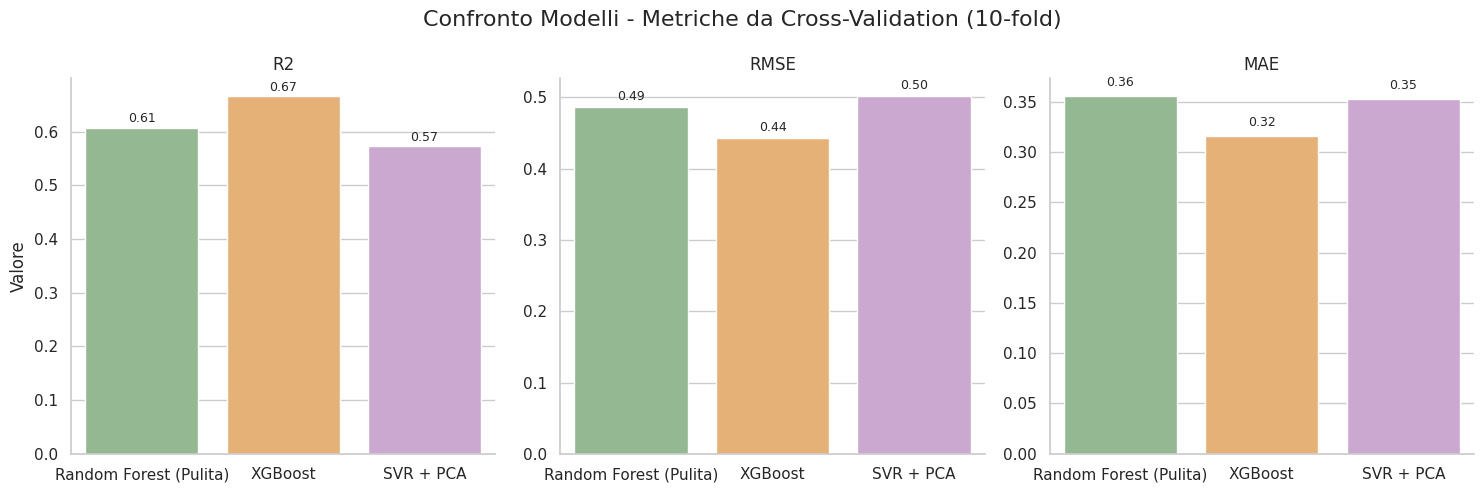

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# === Inserisci qui i risultati della tua cross-validation (valori medi) ===
cv_results = [
    {
        "Modello": "Random Forest (Pulita)",
        "R2": 0.6078,
        "R2_std":  0.0874,
        "RMSE": 0.4865,
        "RMSE_std": 0.0505,
        "MAE": 0.3554,
        "MAE_std": 0.0360
    },
    {
        "Modello": "XGBoost",
        "R2": 0.6662,
        "R2_std": 0.1068,
        "RMSE": 0.4424,
        "RMSE_std": 0.0496,
        "MAE": 0.3154,
        "MAE_std": 0.0358
    },
    {
        "Modello": "SVR + PCA",
        "R2": 0.5733,
        "R2_std": 0.1237,
        "RMSE": 0.5015,
        "RMSE_std": 0.0487,
        "MAE": 0.3524,
        "MAE_std": 0.0358
    }
]

# === Costruzione del DataFrame ===
df_cv = pd.DataFrame(cv_results)
df_long_cv = df_cv.melt(
    id_vars=["Modello"],
    value_vars=["R2", "RMSE", "MAE"],
    var_name="Metrica",
    value_name="Valore"
)
df_long_cv["Metrica"] = pd.Categorical(df_long_cv["Metrica"], categories=["R2", "RMSE", "MAE"], ordered=True)

# === Palette personalizzata ===
palette = {
    'XGBoost': '#F7B264',
    'SVR + PCA': '#CFA1D6',
    'Random Forest (Pulita)': '#8FBF8A'
}

# === Plot comparativo ===
sns.set(style="whitegrid")
g = sns.catplot(
    data=df_long_cv,
    kind='bar',
    x='Modello',
    y='Valore',
    col='Metrica',
    col_wrap=3,
    palette=palette,
    sharey=False
)

# === Etichette e titoli ===
for ax, met in zip(g.axes.flat, ['R2', 'RMSE', 'MAE']):
    ax.set_xlabel("")
    ax.set_title(met)
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.0,
            height + 0.01,
            f'{height:.2f}',
            ha='center',
            fontsize=9
        )

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Confronto Modelli - Metriche da Cross-Validation (10-fold)", fontsize=16)
plt.tight_layout()
plt.show()



Metriche del modello XGBoost:
      R2   RMSE    MAE
0  0.632  0.477  0.333


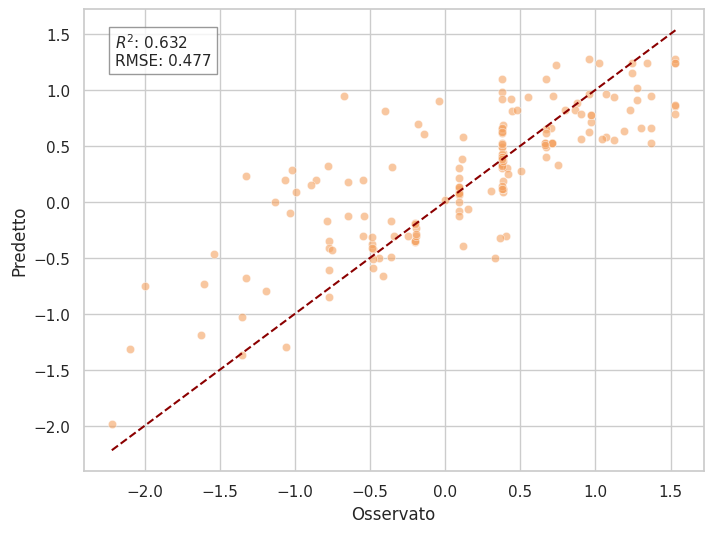

In [ ]:
xgb_prev = xgb_model.predict(X_test_xgb)


# Metriche
xgb_metr = pd.DataFrame({
    'R2': [r2_score(y_test_xgb, xgb_prev)],
    'RMSE': [np.sqrt(mean_squared_error(y_test_xgb, xgb_prev))],
    'MAE': [mean_absolute_error(y_test_xgb, xgb_prev)]
}).round(3)

print("Metriche del modello XGBoost:")
print(xgb_metr)

# Calcolo metriche XGBoost
xgb_r2 = r2_score(y_test_xgb, xgb_prev)
xgb_rmse = np.sqrt(mean_squared_error(y_test_xgb, xgb_prev))

# Scatterplot osservato vs predetto (XGBoost)
df_scatter_xgb = pd.DataFrame({
    'Osservato': y_test_xgb,
    'Predetto': xgb_prev
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_scatter_xgb, x='Osservato', y='Predetto', color='#F4A261', alpha=0.6)

# Linea ideale y = x
min_val = df_scatter_xgb.min().min()
max_val = df_scatter_xgb.max().max()
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='darkred')

# Annotazioni corrette
plt.text(
    0.05, 0.95,
    f"$R^2$: {xgb_r2:.3f}\nRMSE: {xgb_rmse:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
);

=== Performance Random Forest su dati puliti ===
R²:   0.566
RMSE: 0.518
MAE:  0.379


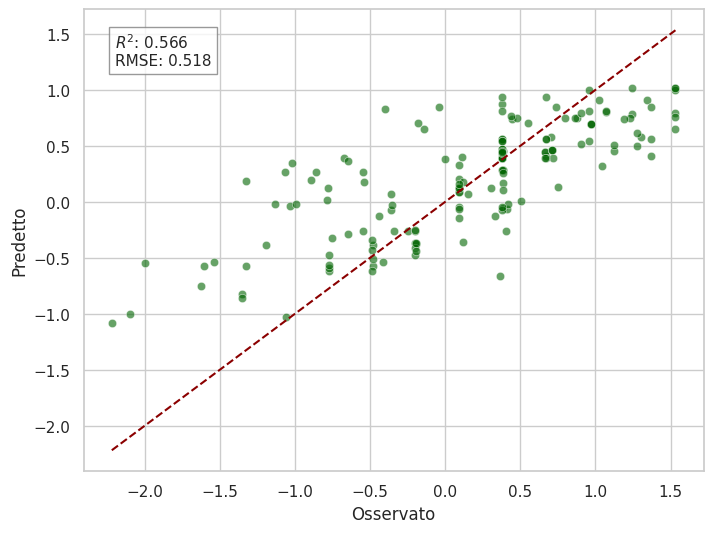

In [ ]:
rf_clean_prev = rf_clean.predict(X_test_clean)


def evaluate_model(actual, predicted):
    return pd.DataFrame({
        'R2': [r2_score(actual, predicted)],
        'RMSE': [np.sqrt(mean_squared_error(actual, predicted))],
        'MAE': [mean_absolute_error(actual, predicted)]
    })

# Calcolo metriche per Random Forest su dati puliti
rf_metrics = evaluate_model(y_test_clean, rf_clean_prev)

# Stampa delle metriche
print("=== Performance Random Forest su dati puliti ===")
print(f"R²:   {rf_metrics['R2'].values[0]:.3f}")
print(f"RMSE: {rf_metrics['RMSE'].values[0]:.3f}")
print(f"MAE:  {rf_metrics['MAE'].values[0]:.3f}")



# Scatterplot osservato vs predetto (RF)
df_scatter_rf = pd.DataFrame({
    'Osservato': y_test_clean,
    'Predetto': rf_clean_prev
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_scatter_rf, x='Osservato', y='Predetto', color='#006400', alpha=0.6)

# Linea ideale y = x
min_val = df_scatter_rf.min().min()
max_val = df_scatter_rf.max().max()
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='darkred')

# Annotazioni corrette
plt.text(
    0.05, 0.95,
    f"$R^2$: {rf_metrics['R2'].values[0]:.3f}\nRMSE: {rf_metrics['RMSE'].values[0]:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
);


=== Performance SVR con PCA ===
R²:   0.396
RMSE: 0.611
MAE:  0.412


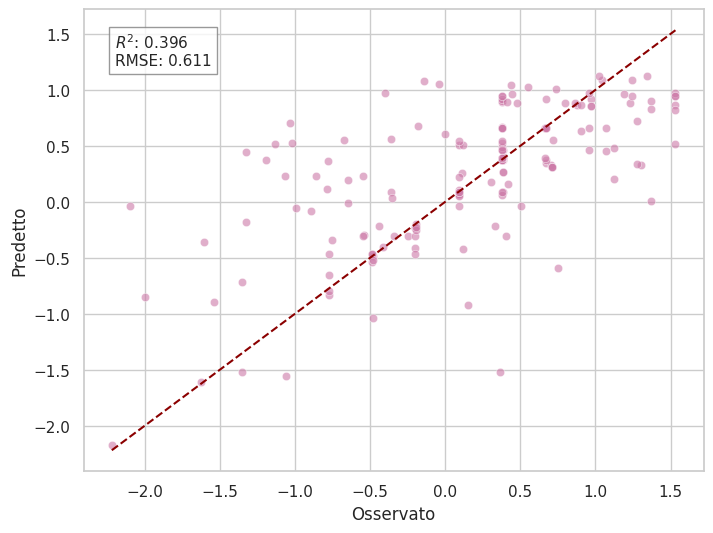

In [ ]:
pca_prev = best_svr.predict(X_test_svr)

# === Metriche ===
r2_pca = r2_score(y_test_svr, pca_prev)
rmse_pca = np.sqrt(mean_squared_error(y_test_svr, pca_prev))
mae_pca = mean_absolute_error(y_test_svr, pca_prev)

print("\n=== Performance SVR con PCA ===")
print(f"R²:   {r2_pca:.3f}")
print(f"RMSE: {rmse_pca:.3f}")
print(f"MAE:  {mae_pca:.3f}")

# Scatterplot osservato vs predetto (RF)
df_scatter_svr = pd.DataFrame({
    'Osservato': y_test_svr,
    'Predetto': pca_prev
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_scatter_svr, x='Osservato', y='Predetto', color='#CC79A7', alpha=0.6)

# Linea ideale y = x
min_val = df_scatter_svr.min().min()
max_val = df_scatter_svr.max().max()
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='darkred')

# Annotazioni corrette
plt.text(
    0.05, 0.95,
    f"$R^2$: {r2_pca:.3f}\nRMSE: {rmse_pca:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
);